# TinyMWAMNet · Notebook 06 — Figures and LaTeX tables

**Runtime:** CPU. Requires Notebooks 01–05. **Time:** about 5 minutes.

Draws every figure of the paper (PDF and 600-dpi PNG

In [ ]:
#@title 1 · Install packages
import importlib.metadata as md, subprocess, sys, os
def _v(p):
    try:
        return md.version(p)
    except md.PackageNotFoundError:
        return None
tfv = _v("tensorflow")
pk = []
if tfv is None:                         # Colab normally ships TensorFlow; install if absent
    pk.append("tensorflow[and-cuda]==2.21.0"); tfv = "2.21.0"
mm = ".".join(tfv.split(".")[:2])
pk += [f"tf_keras~={mm}.0", "setuptools<81"] + ['statsmodels']
if not os.environ.get("TMN_SKIP_PIP"):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pk, check=True)
os.environ["TF_USE_LEGACY_KERAS"] = "1"   # tf_keras (Keras 2) is required by TF-MOT for QAT
print("TensorFlow", tfv, "| installed:", pk)

TensorFlow 2.21.0 | installed: ['tf_keras~=2.21.0', 'setuptools<81', 'statsmodels']


In [ ]:
%%writefile /content/tmn_common.py
"""
TinyMWAMNet — shared utilities for all Colab notebooks.

"""
import os, sys, json, math, time, glob, hashlib, random, gc, re, subprocess, shutil
from concurrent.futures import ThreadPoolExecutor
import numpy as np

VERSION = "30 Sep 2026"      # printed by cell 3 of every notebook

# ---------------------------------------------------------------------------
# 1. Configuration (pre-specified; nothing here is tuned on shifted data)
# ---------------------------------------------------------------------------
CFG = dict(
    # Kaggle dataset identifiers
    DIN_ID="alik05/forest-fire-dataset",                 # in-domain (paper 1)
    WILD_ID="elmadafri/the-wildfire-dataset",            # Shift-1 (anticipated)
    DFIRE_ID="sayedgamal99/smoke-fire-detection-yolo",   # Shift-2 (unanticipated, CC0)
    IMG=224, SEED=42, SEEDS=[42, 43, 44, 45, 46], VAL_FRAC=0.20,
    # teacher (identical to paper 1)
    TEACHER_COPIES=4, HUE=0.10, L2=0.01, DROPOUT=0.5, LR=1e-4, WD=1e-4,
    EPOCHS=100, BATCH=32, PATIENCE=15,
    # augmentation pools for students
    STD_COPIES=8,          # paper-1 augmentation; copies 1-4 are identical to paper 1
    CONF_COPIES=4,         # confounder-aware copies (CAD)
    # students
    KD_T=2.0, KD_ALPHA=0.5,
    ST_BATCH=64, ST_WARM_EPOCHS=3, ST_EPOCHS=25, ST_LR_WARM=1e-3, ST_LR=3e-4,
    ST_WD=1e-4, ST_DROPOUT=0.2, QAT_EPOCHS=5, QAT_LR=5e-5,
    QAT_WARMUP_STEPS=3000,  # forward passes that let tfmot's EMA activation ranges converge (see qat_range_warmup)
    CALIB_N=256,
    # leakage audit
    PHASH_MAX_DIST=6,
    # weight-only bit-width sweep
    WBITS=[8, 6, 5, 4, 3],
    TEST_MODE=bool(int(os.environ.get("TMN_TEST_MODE", "0"))),
)

MAIN_STUDENT = ("mnv3s", 1.0, 128)          # TinyMWAMNet-S
RELU6_STUDENT = ("mnv3s6", 1.0, 128)        # same network, every ReLU capped at 6 (causal test)
FAMILY = [("mnv1", 0.25, 96),                # TinyMWAMNet-XS (MLPerf Tiny VWW size)
          ("mnv3s", 1.0, 96), ("mnv3s", 1.0, 160), ("mnv2", 0.35, 128)]
REGIMES = {  # name: (use KD?, pool kind)
    "CE-std": (False, "std"), "CE-conf": (False, "conf"),
    "KD-std": (True, "std"), "CAD": (True, "conf"),   # CAD = KD + confounder aug
}
EVALSETS = ("din", "wild", "dfire")
EVAL_NAMES = {"din": "In-domain test", "wild": "Shift-1 (The Wildfire Dataset)",
              "dfire": "Shift-2 (D-Fire)"}

if CFG["TEST_MODE"]:
    CFG.update(SEEDS=[42, 43], EPOCHS=3, PATIENCE=2, STD_COPIES=2, CONF_COPIES=2,
               TEACHER_COPIES=1, ST_WARM_EPOCHS=1, ST_EPOCHS=1, QAT_EPOCHS=1,
               CALIB_N=8, WBITS=[8, 4], QAT_WARMUP_STEPS=20)
    FAMILY = [("mnv1", 0.25, 96)]

IMGEXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def log(*a):
    print(time.strftime("[%H:%M:%S]"), *a, flush=True)


# ---------------------------------------------------------------------------
# 2. Paths (Google Drive if mounted, else local)
# ---------------------------------------------------------------------------
def setup_paths():
    root = os.environ.get("TMN_ROOT")
    if not root:
        root = ("/content/drive/MyDrive/TinyMWAMNet"
                if os.path.isdir("/content/drive/MyDrive") else "/content/TinyMWAMNet")
    P = {k: os.path.join(root, k) for k in
         ["data", "features", "models", "results", "preds", "figures", "tflite", "logs"]}
    P["root"] = root
    P["tmp"] = os.environ.get("TMN_TMP", "/content/tmn_tmp")
    for v in P.values():
        os.makedirs(v, exist_ok=True)
    return P


def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=1, default=lambda o: o.item() if hasattr(o, "item") else str(o))


def load_json(path):
    with open(path) as f:
        return json.load(f)


def set_seed(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed); np.random.seed(seed)
    try:
        import tf_keras as keras
        keras.utils.set_random_seed(seed)
    except Exception:
        pass


# ---------------------------------------------------------------------------
# 3. Dataset download and discovery
# ---------------------------------------------------------------------------
def kaggle_download(kid):
    """kagglehub download; TMN_FAKE_DATA=<dir> redirects to local copies (testing)."""
    fake = os.environ.get("TMN_FAKE_DATA")
    if fake:
        return os.path.join(fake, kid.replace("/", "__"))
    import kagglehub
    return kagglehub.dataset_download(kid)


def _load_one(p, S, draft):
    from PIL import Image
    try:
        with Image.open(p) as im:
            if draft:
                im.draft("RGB", (S * 2, S * 2))       # fast DCT-scaled JPEG decode
            return np.asarray(im.convert("RGB").resize((S, S), Image.BILINEAR))
    except Exception as e:
        print("   unreadable, stored as black frame:", os.path.basename(p), e)
        return np.zeros((S, S, 3), np.uint8)


def load_images(paths, S=224, draft=False, workers=8):
    out = np.zeros((len(paths), S, S, 3), np.uint8)
    with ThreadPoolExecutor(workers) as ex:
        for i, a in enumerate(ex.map(lambda p: _load_one(p, S, draft), paths)):
            out[i] = a
    return out


def discover_din(root):
    """Forest Fire Dataset (alik05). Identical file lists and split to paper 1."""
    from sklearn.model_selection import train_test_split
    base = glob.glob(os.path.join(root, "**", "Forest Fire Dataset"), recursive=True)[0]
    tr_dir, te_dir = os.path.join(base, "Training"), os.path.join(base, "Testing")
    pool_p, pool_y = [], []
    for cls, lab in (("nofire", 0), ("fire", 1)):
        fs = sorted(glob.glob(os.path.join(tr_dir, cls, "*.jpg")))
        pool_p += fs; pool_y += [lab] * len(fs)
    pool_y = np.array(pool_y, np.int32)
    te_p = sorted(glob.glob(os.path.join(te_dir, "*.jpg")))
    te_y = np.array([0 if os.path.basename(p).lower().startswith("nofire") else 1
                     for p in te_p], np.int32)
    tr_p, va_p, tr_y, va_y = train_test_split(pool_p, pool_y, test_size=CFG["VAL_FRAC"],
                                              random_state=CFG["SEED"], stratify=pool_y)
    return dict(tr_p=list(tr_p), va_p=list(va_p), te_p=te_p,
                tr_y=np.array(tr_y, np.int32), va_y=np.array(va_y, np.int32), te_y=te_y)


def discover_wild(root):
    """The Wildfire Dataset: labels from 'fire'/'nofire' folders, subclass = leaf folder."""
    recs = []
    for dp, dn, fn in os.walk(root):
        dn.sort()
        parts = [p.lower() for p in dp[len(root):].split(os.sep) if p]
        if any(p == "nofire" for p in parts):
            lab = 0
        elif any(p == "fire" for p in parts):
            lab = 1
        else:
            continue
        sub = parts[-1] if parts[-1] not in ("fire", "nofire") else "unspecified"
        for f in sorted(fn):
            if os.path.splitext(f)[1].lower() in IMGEXT:
                recs.append((os.path.join(dp, f), lab, sub))
    recs.sort(key=lambda r: r[0])
    return dict(paths=[r[0] for r in recs], y=np.array([r[1] for r in recs], np.int32),
                sub=np.array([r[2] for r in recs]))


def _yolo_names(root):
    try:
        import yaml
    except Exception:
        return None
    for y in glob.glob(os.path.join(root, "**", "*.yaml"), recursive=True):
        try:
            d = yaml.safe_load(open(y))
            names = d.get("names") if isinstance(d, dict) else None
            if isinstance(names, dict):
                names = [names[k] for k in sorted(names)]
            if names:
                return [str(n).lower() for n in names]
        except Exception:
            pass
    return None


def discover_dfire(root, prefer=("test",)):
    """D-Fire (YOLO format). fire = >=1 fire box; no-fire = no boxes; smoke-only excluded."""
    lab_dirs = [d for d in glob.glob(os.path.join(root, "**", "labels"), recursive=True)
                if os.path.isdir(os.path.join(os.path.dirname(d), "images"))]
    splits = {os.path.basename(os.path.dirname(d)).lower(): d for d in lab_dirs}
    print("D-Fire splits found:", {k: len(os.listdir(v)) for k, v in splits.items()})
    chosen = [splits[k] for k in prefer if k in splits] or list(splits.values())
    names = _yolo_names(root)
    if names and "fire" in names:
        fire_id = names.index("fire")
    else:
        fire_id = 1                                   # D-Fire convention: 0 smoke, 1 fire
    recs, stats = [], dict(fire=0, none=0, smoke_only=0)
    only = {}
    for ld in chosen:
        imd = os.path.join(os.path.dirname(ld), "images")
        imgs = {os.path.splitext(f)[0]: os.path.join(imd, f) for f in os.listdir(imd)
                if os.path.splitext(f)[1].lower() in IMGEXT}
        for stem, ip in sorted(imgs.items()):
            lf = os.path.join(ld, stem + ".txt")
            cls = []
            if os.path.exists(lf):
                cls = [int(float(l.split()[0])) for l in open(lf) if l.strip()]
            s = set(cls)
            if len(s) == 1:
                only[next(iter(s))] = only.get(next(iter(s)), 0) + 1
            if fire_id in s:
                recs.append((ip, 1, "fire+smoke" if len(s) > 1 else "fire_only")); stats["fire"] += 1
            elif not s:
                recs.append((ip, 0, "none")); stats["none"] += 1
            else:
                stats["smoke_only"] += 1
    print("D-Fire class names:", names, "-> fire id =", fire_id,
          "| images with a single class:", only, "| kept:", stats)
    if only and len(only) == 2 and only.get(fire_id, 0) > only.get(1 - fire_id, 0):
        print("WARNING: the class treated as 'fire' is the more frequent single class; in "
              "D-Fire smoke-only images outnumber fire-only images ~5:1. Check the mapping!")
    return dict(paths=[r[0] for r in recs], y=np.array([r[1] for r in recs], np.int32),
                sub=np.array([r[2] for r in recs]), stats=stats, fire_id=fire_id)


# ---------------------------------------------------------------------------
# 4. Augmentation (paper-1 recipe) and confounder-aware augmentation (CAD)
# ---------------------------------------------------------------------------
def _tf():
    import tensorflow as tf
    return tf


def std_aug_block(X, copy_idx, indices=None, batch=256):
    """Paper-1 augmentation, seeds s=[i, c*7919+13]; returns uint8 array.
    Copies 1..4 are bit-identical to the paper-1 teacher training pool."""
    tf = _tf()
    idx = np.arange(len(X)) if indices is None else np.asarray(indices)
    c = int(copy_idx)

    def aug_one(x_u8, i):
        s = tf.stack([tf.cast(i, tf.int32), tf.constant(c * 7919 + 13, tf.int32)])
        im = tf.cast(x_u8, tf.float32) / 255.0
        im = tf.image.stateless_random_flip_left_right(im, s)
        im = tf.image.stateless_random_brightness(im, 0.10, s + 1)
        im = tf.image.stateless_random_contrast(im, 0.9, 1.1, s + 2)
        im = tf.image.stateless_random_saturation(im, 0.9, 1.1, s + 3)
        im = tf.image.stateless_random_hue(im, CFG["HUE"], s + 4)
        im = tf.clip_by_value(im, 0.0, 1.0)
        im = tf.image.stateless_random_jpeg_quality(im, 75, 100, s + 5)
        return tf.cast(tf.round(im * 255.0), tf.uint8)

    ds = tf.data.Dataset.from_tensor_slices((X[idx], idx.astype(np.int32)))
    ds = ds.map(aug_one, num_parallel_calls=tf.data.AUTOTUNE, deterministic=True).batch(batch)
    with tf.device("/CPU:0"):
        return np.concatenate([b.numpy() for b in ds]) if len(idx) else X[:0].copy()


# ---- confounder transforms (NumPy/SciPy only, deterministic per image) ----
def _warm_cast(im, r):
    """Sunset / golden-hour illumination: channel gains plus a warm sky gradient."""
    g = np.array([r.uniform(1.05, 1.35), r.uniform(0.92, 1.08), r.uniform(0.60, 0.88)])
    out = im * g
    H = im.shape[0]
    ramp = np.linspace(1.0, 0.0, H)[:, None, None] ** r.uniform(0.8, 2.0)
    a = r.uniform(0.15, 0.45) * ramp
    tint = np.array([1.0, r.uniform(0.45, 0.65), r.uniform(0.10, 0.30)])
    return out * (1 - a) + tint * a


def _foliage(im, r):
    """Autumn foliage: rotate green hues towards yellow/red, boost saturation.
    Pure NumPy (matplotlib's HSV conversion); no OpenCV dependency."""
    from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
    hsv = rgb_to_hsv(np.clip(im, 0.0, 1.0).astype(np.float64))
    h = hsv[..., 0] * 360.0                                         # hue in degrees
    green = (h > 55) & (h < 170)
    h[green] = (h[green] - r.uniform(40, 95)) % 360.0
    hsv[..., 0] = h / 360.0
    hsv[..., 1] = np.clip(hsv[..., 1] * np.where(green, r.uniform(1.0, 1.3), 1.0), 0, 1)
    return hsv_to_rgb(hsv)


def _haze(im, r):
    """Fog / haze via the atmospheric scattering model I = J t + A (1 - t)."""
    H = im.shape[0]
    t0 = r.uniform(0.45, 0.85)
    grad = np.linspace(r.uniform(0.0, 0.25), 0.0, H)[:, None, None]  # denser near the top
    t = np.clip(t0 - grad, 0.25, 1.0)
    A = r.uniform(0.75, 0.95) * np.array([1.0, 1.0, r.uniform(0.95, 1.05)])
    return im * t + A * (1 - t)


def _glare(im, r):
    """Sun glare / specular reflection: additive warm Gaussian blob."""
    H, W = im.shape[:2]
    cy, cx = r.uniform(0.05, 0.95) * H, r.uniform(0.05, 0.95) * W
    s = r.uniform(0.08, 0.25) * H
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - cy) ** 2 + (xx - cx) ** 2) / (2 * s * s))[..., None]
    col = np.array([1.0, r.uniform(0.80, 0.95), r.uniform(0.50, 0.75)])
    return im + r.uniform(0.3, 0.8) * g * col


def _line_kernel(L, angle_deg):
    """Normalised L x L linear motion-blur kernel at the given angle (bilinear splatting)."""
    k = np.zeros((L, L), np.float64)
    c = (L - 1) / 2.0
    t = np.linspace(-c, c, 8 * L)
    a = np.deg2rad(angle_deg)
    xs, ys = c + t * np.cos(a), c - t * np.sin(a)
    x0, y0 = np.floor(xs).astype(int), np.floor(ys).astype(int)
    fx, fy = xs - x0, ys - y0
    for dx, dy, w in ((0, 0, (1 - fx) * (1 - fy)), (1, 0, fx * (1 - fy)),
                      (0, 1, (1 - fx) * fy), (1, 1, fx * fy)):
        np.add.at(k, (np.clip(y0 + dy, 0, L - 1), np.clip(x0 + dx, 0, L - 1)), w)
    return k / k.sum()


def _motion(im, r):
    """Camera/platform motion blur: linear kernel of random length and angle.
    SciPy convolution with reflected borders; no OpenCV dependency."""
    from scipy.ndimage import convolve
    L = int(r.choice([5, 7, 9, 11, 13, 15]))
    k = _line_kernel(L, r.uniform(0, 180))
    return np.stack([convolve(im[..., ch].astype(np.float64), k, mode="reflect")
                     for ch in range(im.shape[-1])], axis=-1)


def _lowlight(im, r):
    """Dusk / low light: gamma darkening, slight blue shift and sensor noise."""
    out = im ** r.uniform(1.6, 2.6)
    out = out * np.array([r.uniform(0.85, 1.0), r.uniform(0.9, 1.0), 1.0])
    return out + r.normal(0, r.uniform(0.01, 0.04), im.shape)


CONF_OPS = [("warm_cast", _warm_cast), ("autumn_foliage", _foliage), ("haze", _haze),
            ("glare", _glare), ("motion_blur", _motion), ("low_light", _lowlight)]


def conf_one(img_u8, i, k, force=None):
    """Label-preserving confounder transform of one image (i = index, k = copy)."""
    r = np.random.default_rng([int(i), int(k), 2026])
    im = img_u8.astype(np.float32) / 255.0
    if force is not None:
        ops = [dict(CONF_OPS)[force]]
    else:
        n = 1 if r.uniform() < 0.6 else 2
        ops = [CONF_OPS[j][1] for j in r.choice(len(CONF_OPS), n, replace=False)]
    for f in ops:
        im = np.clip(f(im, r), 0.0, 1.0)
    return np.round(im * 255.0).astype(np.uint8)


def conf_aug_block(X, copy_idx, indices=None, workers=8):
    """Confounder copy k: paper-1 augmentation (seed family 100+k) then 1-2 confounders."""
    idx = np.arange(len(X)) if indices is None else np.asarray(indices)
    base = std_aug_block(X, 100 + int(copy_idx), idx)
    out = np.empty_like(base)
    with ThreadPoolExecutor(workers) as ex:
        for j, a in enumerate(ex.map(lambda t: conf_one(t[1], t[0], copy_idx),
                                     zip(idx, base))):
            out[j] = a
    return out


def pool_blocks():
    """Ordered list of augmentation blocks forming the full student pool."""
    return ([("orig", 0)] + [("std", c) for c in range(1, CFG["STD_COPIES"] + 1)]
            + [("conf", k) for k in range(1, CFG["CONF_COPIES"] + 1)])


def regime_blocks(kind):
    """Blocks used by a student regime. Both regimes have the same number of images."""
    if kind == "std":
        return [("orig", 0)] + [("std", c) for c in range(1, CFG["STD_COPIES"] + 1)]
    half = CFG["STD_COPIES"] - CFG["CONF_COPIES"]
    return ([("orig", 0)] + [("std", c) for c in range(1, half + 1)]
            + [("conf", k) for k in range(1, CFG["CONF_COPIES"] + 1)])


def teacher_blocks():
    return [("orig", 0)] + [("std", c) for c in range(1, CFG["TEACHER_COPIES"] + 1)]


def make_block(X, kind, c, indices=None):
    if kind == "orig":
        return X if indices is None else X[np.asarray(indices)]
    if kind == "std":
        return std_aug_block(X, c, indices)
    return conf_aug_block(X, c, indices)


def array_md5(a):
    return hashlib.md5(np.ascontiguousarray(a).tobytes()).hexdigest()


def fingerprint(a, n=20000):
    """MD5 plus a fixed random sample of pixel values (to quantify tiny cross-machine drift)."""
    flat = np.ascontiguousarray(a).reshape(-1)
    idx = np.random.default_rng(0).integers(0, flat.size, n)
    return dict(md5=array_md5(flat), sample=flat[idx].astype(int).tolist())


def compare_fingerprint(a, fp):
    flat = np.ascontiguousarray(a).reshape(-1)
    if array_md5(flat) == fp["md5"]:
        return dict(identical=True, frac_diff=0.0, max_diff=0)
    idx = np.random.default_rng(0).integers(0, flat.size, len(fp["sample"]))
    d = np.abs(flat[idx].astype(int) - np.asarray(fp["sample"]))
    return dict(identical=False, frac_diff=float((d > 0).mean()), max_diff=int(d.max()))


# ---------------------------------------------------------------------------
# 5. Perceptual-hash leakage audit
# ---------------------------------------------------------------------------
def phash_array(X):
    import imagehash
    from PIL import Image
    return np.array([int(str(imagehash.phash(Image.fromarray(x))), 16) for x in X],
                    dtype=np.uint64)


def min_hamming(a, b, chunk=512):
    """For each hash in a, the minimum Hamming distance to any hash in b."""
    out = np.empty(len(a), np.int32)
    b = b.astype(np.uint64)
    for s in range(0, len(a), chunk):
        x = np.bitwise_xor(a[s:s + chunk, None].astype(np.uint64), b[None, :])
        d = np.unpackbits(x.view(np.uint8).reshape(x.shape + (8,)), axis=-1).sum(-1)
        out[s:s + chunk] = d.min(1)
    return out


# ---------------------------------------------------------------------------
# 6. Teacher (MWAMNet) — identical architecture and protocol to paper 1
# ---------------------------------------------------------------------------
def keras_mod():
    os.environ.setdefault("TF_USE_LEGACY_KERAS", "1")
    import tf_keras as keras
    return keras


def teacher_backbones(weights="imagenet"):
    keras = keras_mod()
    if CFG["TEST_MODE"]:
        weights = None
        set_seed(0)                      # deterministic random backbones in test mode
    S = CFG["IMG"]
    d = keras.applications.DenseNet201(include_top=False, weights=weights,
                                       input_shape=(S, S, 3), pooling="avg")
    m = keras.applications.MobileNetV3Large(include_top=False, weights=weights,
                                            input_shape=(S, S, 3), pooling="avg")
    d.trainable = False; m.trainable = False
    return d, m


def densenet_prep(x):
    """== keras.applications.densenet.preprocess_input (mode 'torch')."""
    tf = _tf()
    x = tf.cast(x, tf.float32) / 255.0
    return (x - tf.constant([0.485, 0.456, 0.406])) / tf.constant([0.229, 0.224, 0.225])


def mnv3_prep(x):
    """== keras.applications.mobilenet_v3.preprocess_input (identity; model rescales)."""
    return _tf().cast(x, "float32")


def extract_features(net, prep, X, bs=64):
    tf = _tf()
    out = np.empty((len(X), net.output_shape[-1]), np.float32)
    i = 0
    while i < len(X):
        try:
            b = X[i:i + bs]
            out[i:i + len(b)] = net(prep(b), training=False).numpy()
            i += len(b)
        except tf.errors.ResourceExhaustedError:
            if bs == 1:
                raise
            bs //= 2; gc.collect()
    return out


def build_head(dims=(1920, 960), l2v=None, drop=None, units=(1024, 512)):
    """Paper-1 head. Final Dense is split into 'logit' + sigmoid (mathematically identical)."""
    keras = keras_mod(); L = keras.layers
    l2v = CFG["L2"] if l2v is None else l2v
    drop = CFG["DROPOUT"] if drop is None else drop
    ins = [keras.Input(shape=(d,)) for d in dims]
    br = [L.Dropout(drop)(L.BatchNormalization()(i)) for i in ins]
    x = L.Concatenate()(br) if len(br) > 1 else br[0]
    for u in units:
        x = L.Dense(u, activation="relu", kernel_regularizer=keras.regularizers.l2(l2v))(x)
        x = L.BatchNormalization()(x)
        x = L.Dropout(drop)(x)
    z = L.Dense(1, name="logit")(x)
    p = L.Activation("sigmoid", name="prob")(z)
    return keras.Model(ins, p, name="mwamnet_head")


def head_logit_model(head):
    keras = keras_mod()
    return keras.Model(head.inputs, head.get_layer("logit").output)


def train_head(Xtr, ytr, Xva, yva, seed):
    keras = keras_mod()
    set_seed(seed)
    steps = math.ceil(len(ytr) / CFG["BATCH"]) * CFG["EPOCHS"]
    lr = keras.optimizers.schedules.CosineDecay(CFG["LR"], steps, alpha=1e-6)
    m = build_head([f.shape[1] for f in Xtr])
    m.compile(optimizer=keras.optimizers.AdamW(learning_rate=lr, weight_decay=CFG["WD"]),
              loss="binary_crossentropy", metrics=["accuracy"])
    h = m.fit(Xtr, ytr, validation_data=(Xva, yva), epochs=CFG["EPOCHS"],
              batch_size=CFG["BATCH"], verbose=0,
              callbacks=[keras.callbacks.EarlyStopping(
                  monitor="val_accuracy", mode="max", patience=CFG["PATIENCE"],
                  restore_best_weights=True)])
    return m, len(h.history["loss"])


def build_teacher_e2e(head_weights, d=None, m=None):
    """End-to-end MWAMNet: raw pixels [0,255] (224x224x3) -> P(fire)."""
    keras = keras_mod(); L = keras.layers
    if d is None:
        d, m = teacher_backbones()
    inp = keras.Input((CFG["IMG"], CFG["IMG"], 3), name="pixels")
    xd = L.Rescaling(1.0 / 255.0)(inp)
    xd = L.Normalization(mean=[0.485, 0.456, 0.406],
                         variance=[0.229 ** 2, 0.224 ** 2, 0.225 ** 2])(xd)
    fd = d(xd, training=False)
    fm = m(inp, training=False)
    head = build_head([d.output_shape[-1], m.output_shape[-1]])
    head.load_weights(head_weights)
    return keras.Model(inp, head([fd, fm]), name="MWAMNet")


# ---------------------------------------------------------------------------
# 7. Students (TinyMWAMNet)
# ---------------------------------------------------------------------------
def student_name(arch, alpha, res):
    return {"mnv3s": "MNv3S", "mnv3s6": "MNv3S6", "mnv1": "MNv1", "mnv2": "MNv2"}[arch] + f"-{alpha:g}-{res}"


def build_student(arch, alpha, res, weights="imagenet"):
    """Flat functional student core. Input in [-1, 1]; output = fire logit."""
    keras = keras_mod(); L = keras.layers
    if CFG["TEST_MODE"]:
        weights = None
    kw = dict(input_shape=(res, res, 3), include_top=False, weights=weights, pooling="avg")
    if arch in ("mnv3s", "mnv3s6"):
        base = keras.applications.MobileNetV3Small(alpha=alpha, minimalistic=True,
                                                   include_preprocessing=False, **kw)
        if arch == "mnv3s6":
            base = relu6_clone(base)
    elif arch == "mnv1":
        base = keras.applications.MobileNet(alpha=alpha, **kw)
    elif arch == "mnv2":
        base = keras.applications.MobileNetV2(alpha=alpha, **kw)
    else:
        raise ValueError(arch)
    x = L.Dropout(CFG["ST_DROPOUT"], name="st_dropout")(base.output)
    z = L.Dense(1, name="logit")(x)
    core = keras.Model(base.input, z, name="core_" + student_name(arch, alpha, res).replace(".", "p"))
    return core


def relu6_clone(base):
    """Same network and weights, but every unbounded ReLU becomes ReLU6 (activations capped at 6)."""
    keras = keras_mod(); L = keras.layers

    def cf(layer):
        if isinstance(layer, L.ReLU) and layer.max_value is None:
            return L.ReLU(max_value=6.0, name=layer.name)
        return layer.__class__.from_config(layer.get_config())
    new = keras.models.clone_model(base, clone_function=cf)
    new.set_weights(base.get_weights())
    n = sum(isinstance(l, L.ReLU) and l.max_value is not None for l in new.layers)
    assert n > 0, "no ReLU layer was capped"
    return new


def qat_range_warmup(qmodel, ds, steps):
    """tfmot initialises every activation range at [-6, 6] and updates it by an exponential
    moving average (decay 0.999) only in training mode. A short QAT run (~850 steps) leaves ~40 %
    of that initial value in the ranges. Running `steps` forward passes in training mode (no weight
    update; BN frozen) lets the ranges converge to the data before fine-tuning (0.999^3000 = 0.05)."""
    tf = _tf()

    @tf.function
    def fwd(x):
        qmodel(x, training=True)
    n = 0
    while n < steps:
        for xb, _ in ds:
            fwd(xb); n += 1
            if n >= steps:
                break
    return n


def set_backbone_trainable(core, flag):
    keras = keras_mod()
    for l in core.layers:
        if l.name in ("logit", "st_dropout"):
            l.trainable = True
        elif isinstance(l, keras.layers.BatchNormalization):
            l.trainable = False          # BN statistics frozen during fine-tuning
        else:
            l.trainable = flag


def kd_loss(alpha, T):
    """alpha*BCE(y, s) + (1-alpha)*T^2*BCE(sigma(t/T), sigma(s/T)); y_true=[y, t_logit]."""
    tf = _tf()

    def loss(y_true, z_s):
        y = y_true[:, 0:1]; zt = y_true[:, 1:2]
        hard = tf.nn.sigmoid_cross_entropy_with_logits(labels=y, logits=z_s)
        if alpha >= 1.0:
            return tf.reduce_mean(hard)
        soft = tf.nn.sigmoid_cross_entropy_with_logits(labels=tf.sigmoid(zt / T),
                                                       logits=z_s / T) * (T * T)
        return tf.reduce_mean(alpha * hard + (1.0 - alpha) * soft)
    return loss


def to_unit(x_u8):
    """uint8 pixels -> x = (pixel - 128) / 128 in [-1, 0.992].
    With this convention the INT8 input tensor of the deployed student is exactly
    q = pixel - 128 (scale 1/128, zero point 0): one subtraction on the MCU."""
    return (x_u8.astype(np.float32) - 128.0) / 128.0


def export_wrapper(core_or_qat, res):
    """Deployed student: x = (pixel-128)/128 -> core -> sigmoid (P(fire))."""
    keras = keras_mod(); L = keras.layers
    inp = keras.Input((res, res, 3), name="pixels_centered")
    p = L.Activation("sigmoid", name="prob")(core_or_qat(inp))
    return keras.Model(inp, p)


def rep_unit(X_u8, n=None, seed=0):
    """Representative data for students (x in [-1, 0.992]); the first sample spans the full
    pixel range so that the converter derives input scale 1/128 and zero point 0 exactly."""
    n = len(X_u8) if n is None else min(n, len(X_u8))
    idx = np.random.default_rng(seed).choice(len(X_u8), n, replace=False)
    ext = np.zeros((1,) + X_u8.shape[1:], np.uint8); ext[:, ::2] = 255

    def gen():
        yield [to_unit(ext)]
        for i in idx:
            yield [to_unit(X_u8[i:i + 1])]
    return gen


def resize_u8(X, res, bs=512):
    """Antialiased bilinear downsampling of uint8 images to res x res (uint8)."""
    tf = _tf()
    if X.shape[1] == res:
        return X
    out = np.empty((len(X), res, res, 3), np.uint8)
    with tf.device("/CPU:0"):
        for s in range(0, len(X), bs):
            r = tf.image.resize(tf.cast(X[s:s + bs], tf.float32), (res, res),
                                method="bilinear", antialias=True)
            out[s:s + bs] = tf.cast(tf.clip_by_value(tf.round(r), 0, 255), tf.uint8).numpy()
    return out


# ---------------------------------------------------------------------------
# 8. TFLite conversion, LiteRT / TFLM runners, Vela
# ---------------------------------------------------------------------------
def tflite_convert(model, res, mode, rep=None, in_type="uint8"):
    """mode: fp32 | fp16 | dyn | int8 (full-integer; input uint8 (teacher, raw pixels) or
    int8 (students, pixel-128); output uint8 probability, scale 1/256)."""
    tf = _tf()

    @tf.function(input_signature=[tf.TensorSpec([1, res, res, 3], tf.float32)])
    def serve(x):
        return model(x, training=False)

    c = tf.lite.TFLiteConverter.from_concrete_functions([serve.get_concrete_function()], model)
    if mode == "fp16":
        c.optimizations = [tf.lite.Optimize.DEFAULT]
        c.target_spec.supported_types = [tf.float16]
    elif mode == "dyn":
        c.optimizations = [tf.lite.Optimize.DEFAULT]
    elif mode == "int8":
        c.optimizations = [tf.lite.Optimize.DEFAULT]
        c.representative_dataset = rep
        c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        c.inference_input_type = tf.int8 if in_type == "int8" else tf.uint8
        c.inference_output_type = tf.uint8
    elif mode != "fp32":
        raise ValueError(mode)
    return c.convert()


def rep_from(X_u8, n=None, seed=0):
    """Representative dataset generator (float pixels in [0,255], batch 1)."""
    n = len(X_u8) if n is None else min(n, len(X_u8))
    idx = np.random.default_rng(seed).choice(len(X_u8), n, replace=False)

    def gen():
        for i in idx:
            yield [X_u8[i:i + 1].astype(np.float32)]
    return gen


LAST_BACKEND = None     # runtime used by the most recent LiteRT call (stored with every result)


def _litert():
    try:
        from ai_edge_litert import interpreter as lit
        return lit
    except Exception:
        return None


def _runtime_candidates(kernels="auto"):
    """Fallback chain. XNNPACK is fastest, but it cannot prepare some INT8 graphs
    (e.g. MobileNetV3 blocks in some TensorFlow builds): the built-in kernels always work.
    kernels="ref" keeps only the built-in (reference-equivalent) kernels, whose integer arithmetic
    matches TensorFlow Lite Micro, i.e. what the microcontroller executes."""
    import warnings
    warnings.filterwarnings("ignore", message=".*tf.lite.Interpreter is deprecated.*")
    tf = _tf(); lit = _litert(); c = []
    if lit is not None:
        c.append(("litert-xnnpack", lit.Interpreter, {}))
    c.append(("tflite-xnnpack", tf.lite.Interpreter, {}))
    if lit is not None:
        c.append(("litert-builtin", lit.Interpreter,
                  {"experimental_op_resolver_type": lit.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES}))
    c.append(("tflite-builtin", tf.lite.Interpreter,
              {"experimental_op_resolver_type": tf.lite.experimental.OpResolverType.BUILTIN_WITHOUT_DEFAULT_DELEGATES}))
    skip = [x for x in os.environ.get("TMN_SKIP_RUNTIMES", "").split(",") if x]
    if kernels == "ref":
        c = [x for x in c if x[0].endswith("builtin")]
    return [x for x in c if x[0] not in skip]


_RUNTIME_OK = {}        # model fingerprint -> runtime that worked (skips known failures)


def make_interpreter(model_bytes, threads=2, batch=None, verbose=True, kernels="auto",
                     preserve_all=False):
    """Allocated, smoke-tested interpreter; tries each runtime in turn. Returns (it, name)."""
    global LAST_BACKEND
    key = (len(model_bytes), hash(model_bytes), kernels, preserve_all)
    cands = _runtime_candidates(kernels)
    if key in _RUNTIME_OK:                    # the runtime that worked last time goes first
        cands = sorted(cands, key=lambda c: c[0] != _RUNTIME_OK[key])
    err = None
    for name, cls, kw in cands:
        try:
            kw2 = dict(kw, experimental_preserve_all_tensors=True) if preserve_all else kw
            it = cls(model_content=model_bytes, num_threads=threads, **kw2)
            ind = it.get_input_details()[0]
            if batch:
                it.resize_tensor_input(ind["index"], [batch] + list(ind["shape"][1:]))
            it.allocate_tensors()
            ind = it.get_input_details()[0]
            it.set_tensor(ind["index"], np.zeros(ind["shape"], ind["dtype"])); it.invoke()
            LAST_BACKEND = name; _RUNTIME_OK[key] = name
            return it, name
        except Exception as e:
            err = e
            if verbose:
                print("   runtime %s cannot run this model (%s) -> trying the next one"
                      % (name, str(e).split("\n")[0][:90]))
    raise err


def quantize_input(xb_u8, dtype, scale, zp):
    """Map uint8 camera pixels to the model's input tensor."""
    if dtype == np.uint8:
        if abs(scale - 1.0) < 1e-3 and zp == 0:
            return xb_u8
        return np.clip(np.round(xb_u8 / scale + zp), 0, 255).astype(np.uint8)
    if dtype == np.int8:                      # students: x = (p-128)/128
        if abs(scale - 1 / 128) < 1e-7 and zp == 0:
            return (xb_u8.astype(np.int16) - 128).astype(np.int8)
        return np.clip(np.round(to_unit(xb_u8) / scale + zp), -128, 127).astype(np.int8)
    return xb_u8.astype(np.float32)           # float models (teacher FP32/FP16/dynamic)


def tflite_predict(model_bytes, X_u8, bs=16, threads=2, kernels="auto"):
    """Batched LiteRT/TFLite inference; returns P(fire) as float32 (runtime in LAST_BACKEND).
    kernels="ref": built-in reference-equivalent kernels only (matches the MCU arithmetic)."""
    it, _ = make_interpreter(model_bytes, threads, batch=bs, kernels=kernels)
    ind, outd = it.get_input_details()[0], it.get_output_details()[0]
    in_s, in_z = ind["quantization"]; out_s, out_z = outd["quantization"]
    out = np.empty(len(X_u8), np.float32)
    for s in range(0, len(X_u8), bs):
        xb = X_u8[s:s + bs]
        n = len(xb)
        if n < bs:
            xb = np.concatenate([xb, np.zeros((bs - n,) + xb.shape[1:], xb.dtype)])
        xin = quantize_input(xb, ind["dtype"], in_s, in_z)
        it.set_tensor(ind["index"], xin); it.invoke()
        o = it.get_tensor(outd["index"]).reshape(bs, -1)[:n, 0]
        out[s:s + n] = (o.astype(np.float32) - out_z) * out_s if outd["dtype"] != np.float32 else o
    return out


def tflite_latency(model_bytes, threads=1, warm=50, runs=200):
    """Median single-image latency (ms) with the first runtime that can run the model."""
    it, _ = make_interpreter(model_bytes, threads, batch=None)
    ind = it.get_input_details()[0]
    x = np.random.default_rng(0).integers(0, 255, ind["shape"]).astype(ind["dtype"])
    for _ in range(warm):
        it.set_tensor(ind["index"], x); it.invoke()
    ts = []
    for _ in range(runs):
        t = time.perf_counter(); it.set_tensor(ind["index"], x); it.invoke()
        ts.append(time.perf_counter() - t)
    return float(np.median(ts) * 1e3)


_TFLM_PROBE = r'''
import sys, numpy as np
from tflite_micro.python.tflite_micro import runtime as r
buf = open(sys.argv[1], "rb").read()
it = r.Interpreter.from_bytes(buf)
d = it.get_input_details(0)
it.set_input(np.zeros(d["shape"], d["dtype"]), 0); it.invoke(); it.print_allocations()
'''


def tflm_arena_bytes(tflite_path):
    """Exact tensor-arena size recorded by the TFLite Micro RecordingMicroAllocator."""
    probe = "/tmp/_tmn_tflm_probe.py"
    open(probe, "w").write(_TFLM_PROBE)
    r = subprocess.run([sys.executable, probe, tflite_path], capture_output=True, text=True)
    m = re.search(r"Arena allocation total (\d+)", r.stdout + r.stderr)
    return int(m.group(1)) if m else None


def tflm_predict_u8(tflite_path, X_u8):
    """Run the TFLite Micro reference runtime (the MCU arithmetic) on uint8 images."""
    from tflite_micro.python.tflite_micro import runtime as r
    it = r.Interpreter.from_bytes(open(tflite_path, "rb").read())
    d = it.get_input_details(0); q = d["quantization_parameters"]
    s, z = float(q["scales"][0]), int(q["zero_points"][0])
    out = np.empty(len(X_u8), np.int32)
    for i in range(len(X_u8)):
        it.set_input(quantize_input(X_u8[i:i + 1], d["dtype"], s, z), 0); it.invoke()
        out[i] = int(np.asarray(it.get_output(0)).ravel()[0])
    return out


def tflite_raw_u8(model_bytes, X_u8, kernels="auto"):
    it, _ = make_interpreter(model_bytes, 2, batch=None, kernels=kernels)
    ind, outd = it.get_input_details()[0], it.get_output_details()[0]
    s, z = ind["quantization"]
    out = np.empty(len(X_u8), np.int32)
    for i in range(len(X_u8)):
        it.set_tensor(ind["index"], quantize_input(X_u8[i:i + 1], ind["dtype"], s, z)); it.invoke()
        out[i] = int(it.get_tensor(outd["index"]).ravel()[0])
    return out


def _vela_cmd():
    exe = shutil.which("vela") or os.path.join(os.path.dirname(sys.executable), "vela")
    return [exe] if os.path.exists(exe) else [sys.executable, "-m", "ethosu.vela"]


def vela_estimate(tflite_path, outdir, accel="ethos-u55-128"):
    outdir = os.path.join(outdir, accel)          # one folder per accelerator configuration
    shutil.rmtree(outdir, ignore_errors=True)
    os.makedirs(outdir, exist_ok=True)
    try:
        r = subprocess.run(_vela_cmd() + [tflite_path, "--accelerator-config", accel,
                                          "--output-dir", outdir], capture_output=True, text=True)
    except OSError as e:
        print("Vela could not be started (%s); the NPU estimate is skipped." % e)
        return None
    stem = os.path.splitext(os.path.basename(tflite_path))[0]
    cs = glob.glob(os.path.join(outdir, stem + "_summary_*.csv"))
    if not cs:
        print("Vela failed:", r.stdout[-800:], r.stderr[-800:])
        return None
    import csv
    row = list(csv.DictReader(open(cs[0])))[0]
    return dict(vela_accel=accel, vela_ms=float(row["inference_time"]) * 1e3,
                vela_sram_KiB=float(row["sram_memory_used"]),
                vela_flash_KiB=float(row.get("off_chip_flash_memory_used", 0) or 0),
                vela_macs=int(float(row["nn_macs"])), vela_cycles=int(float(row["cycles_total"])))


def count_macs(model, res):
    """Multiply-accumulate count of the float graph (TF profiler FLOPs / 2)."""
    tf = _tf()
    from tensorflow.python.framework.convert_to_constants import \
        convert_variables_to_constants_v2_as_graph
    f = tf.function(lambda x: model(x, training=False)).get_concrete_function(
        tf.TensorSpec([1, res, res, 3], tf.float32))
    frozen, _ = convert_variables_to_constants_v2_as_graph(f)
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    opts["output"] = "none"
    prof = tf.compat.v1.profiler.profile(graph=frozen.graph, run_meta=tf.compat.v1.RunMetadata(),
                                         cmd="op", options=opts)
    return int(prof.total_float_ops // 2)


# ---------------------------------------------------------------------------
# 9. Weight-only fake quantisation (bit-width sweep)
# ---------------------------------------------------------------------------
def _iter_layers(model):
    keras = keras_mod()
    for l in model.layers:
        if isinstance(l, keras.Model):
            yield from _iter_layers(l)
        else:
            yield l


def fake_quant_weights(model, bits):
    """Per-output-channel symmetric b-bit quantisation of every Conv/Depthwise/Dense
    kernel, in place. Returns a backup list for restore_weights()."""
    keras = keras_mod()
    qmax = 2 ** (bits - 1) - 1
    backup = []
    for l in _iter_layers(model):
        if isinstance(l, keras.layers.DepthwiseConv2D):
            axes = (0, 1)                      # kernel (kh, kw, channels, multiplier)
        elif isinstance(l, (keras.layers.Conv2D, keras.layers.Dense)):
            axes = tuple(range(len(l.kernel.shape) - 1))   # per output channel
        else:
            continue
        var = l.depthwise_kernel if isinstance(l, keras.layers.DepthwiseConv2D) else l.kernel
        W = var.numpy()
        backup.append((var, W.copy()))
        s = np.maximum(np.abs(W).max(axis=axes, keepdims=True), 1e-12) / qmax
        var.assign(np.clip(np.round(W / s), -qmax, qmax) * s)
    return backup


def restore_weights(backup):
    for var, W in backup:
        var.assign(W)


# ---------------------------------------------------------------------------
# 10. Metrics and statistics
# ---------------------------------------------------------------------------
def ece_score(y, p, bins=15):
    """Expected calibration error of P(fire) (binary, equal-width bins)."""
    y = np.asarray(y); p = np.asarray(p, float)
    e = np.linspace(0, 1, bins + 1); tot = 0.0
    for a, b in zip(e[:-1], e[1:]):
        m = (p > a) & (p <= b) if a > 0 else (p >= a) & (p <= b)
        if m.any():
            tot += m.mean() * abs(y[m].mean() - p[m].mean())
    return float(tot)


def metrics(y, p, thr=0.5):
    from sklearn.metrics import roc_auc_score, average_precision_score
    y = np.asarray(y).astype(int); p = np.asarray(p, float); yp = (p > thr).astype(int)
    tp = int(((yp == 1) & (y == 1)).sum()); tn = int(((yp == 0) & (y == 0)).sum())
    fp = int(((yp == 1) & (y == 0)).sum()); fn = int(((yp == 0) & (y == 1)).sum())
    rec = tp / max(tp + fn, 1); spec = tn / max(tn + fp, 1); prec = tp / max(tp + fp, 1)
    two = len(np.unique(y)) == 2
    return dict(n=len(y), acc=(tp + tn) / len(y), bacc=(rec + spec) / 2, recall=rec,
                specificity=spec, precision=prec,
                f1=2 * prec * rec / max(prec + rec, 1e-12),
                auc=roc_auc_score(y, p) if two else np.nan,
                ap=average_precision_score(y, p) if two else np.nan,
                ece=ece_score(y, p), brier=float(np.mean((p - y) ** 2)),
                tp=tp, tn=tn, fp=fp, fn=fn)


def wilson(k, n, z=1.959964):
    if n == 0:
        return (np.nan, np.nan)
    ph = k / n; d = 1 + z * z / n
    c = (ph + z * z / (2 * n)) / d
    h = z * math.sqrt(ph * (1 - ph) / n + z * z / (4 * n * n)) / d
    return (c - h, c + h)


def mcnemar_p(y, pa, pb, thr=0.5):
    """Two-sided McNemar test on paired correctness (exact if discordant < 25)."""
    from statsmodels.stats.contingency_tables import mcnemar
    a = ((np.asarray(pa) > thr).astype(int) == y); b = ((np.asarray(pb) > thr).astype(int) == y)
    n01, n10 = int((a & ~b).sum()), int((~a & b).sum())
    if n01 + n10 == 0:
        return 1.0, n01, n10
    r = mcnemar([[int((a & b).sum()), n01], [n10, int((~a & ~b).sum())]],
                exact=(n01 + n10) < 25, correction=True)
    return float(r.pvalue), n01, n10


def holm(pvals):
    from statsmodels.stats.multitest import multipletests
    return multipletests(pvals, method="holm")[1]


def flips(y, p_ref, p_new, thr=0.5):
    a = (np.asarray(p_ref) > thr).astype(int); b = (np.asarray(p_new) > thr).astype(int)
    f = a != b
    return dict(flip_rate=float(f.mean()), n_flip=int(f.sum()),
                new_missed_fires=int((f & (y == 1) & (b == 0)).sum()),
                new_false_alarms=int((f & (y == 0) & (b == 1)).sum()),
                fixed=int((f & (b == y)).sum()), broken=int((f & (a == y)).sum()))


def paired_bootstrap(y, pa, pb, fn="bacc", B=2000, seed=0, thr=0.5):
    """95% CI of metric(pb) - metric(pa) by paired bootstrap over images."""
    rng = np.random.default_rng(seed); y = np.asarray(y); n = len(y)
    f = (lambda yy, pp: metrics(yy, pp, thr)[fn])
    d0 = f(y, pb) - f(y, pa); ds = []
    for _ in range(B):
        i = rng.integers(0, n, n)
        if len(np.unique(y[i])) < 2:
            continue
        ds.append(f(y[i], pb[i]) - f(y[i], pa[i]))
    lo, hi = np.percentile(ds, [2.5, 97.5])
    return float(d0), float(lo), float(hi)


# ---------------------------------------------------------------------------
# 11. Result bookkeeping (resumable)
# ---------------------------------------------------------------------------
def labels(P):
    return dict(np.load(os.path.join(P["data"], "labels.npz"), allow_pickle=True))


def teacher_soft(P):
    """Teacher-ensemble soft labels (logits) for every pool block: {'orig_0': array, ...}."""
    d = np.load(os.path.join(P["data"], "teacher_soft.npz"))
    return {k: d[k] for k in d.files}


def pred_path(P, model_id):
    return os.path.join(P["preds"], model_id + ".npz")


def have_preds(P, model_id):
    return os.path.exists(pred_path(P, model_id))


def save_preds(P, model_id, preds, meta, idx=None):
    """Per-image P(fire). If idx is given, preds[ds] belongs to images idx[ds] of set ds."""
    extra = {"idx_" + k: np.asarray(v, np.int32) for k, v in (idx or {}).items()}
    np.savez_compressed(pred_path(P, model_id), meta=json.dumps(meta), **extra,
                        **{k: np.asarray(v, np.float32) for k, v in preds.items()})


def load_preds(P, model_id):
    """Returns (preds, meta, idx); idx[ds] is None when the full set was evaluated."""
    d = np.load(pred_path(P, model_id), allow_pickle=True)
    preds = {k: d[k] for k in d.files if k != "meta" and not k.startswith("idx_")}
    idx = {k: (d["idx_" + k] if "idx_" + k in d.files else None) for k in preds}
    return preds, json.loads(str(d["meta"])), idx


def metric_rows(P, model_id, preds, meta, idx=None):
    lab = labels(P); rows = []
    for ds in EVALSETS:
        if ds in preds:
            y = lab["y_" + ds] if not idx or idx.get(ds) is None else lab["y_" + ds][idx[ds]]
            r = dict(meta); r.update(model_id=model_id, dataset=ds)
            r.update(metrics(y, preds[ds])); rows.append(r)
    return rows


def ladder_subsets(P, n=1000, seed=42):
    """Fixed evaluation subsets for the teacher's TFLite ladder: the whole in-domain test set
    and a label-stratified random sample of n images from each shifted set.
    A per-class random order is drawn once and saved (data/ladder_order.json); the subset of
    size n is the first round(n * class share) images of each class, so subsets for different
    n are nested (a 600-image subset lies inside the 1,000-image one)."""
    f = os.path.join(P["data"], "ladder_order.json")
    lab = labels(P)
    if os.path.exists(f):
        order = {k: np.array(v, np.int64) for k, v in load_json(f).items()}
    else:
        rng = np.random.default_rng(seed); order = {}
        for ds in EVALSETS:
            y = lab["y_" + ds]
            for c in (0, 1):
                order[f"{ds}_{c}"] = rng.permutation(np.where(y == c)[0])
        save_json({k: v.tolist() for k, v in order.items()}, f)
    out = {}
    for ds in EVALSETS:
        y = lab["y_" + ds]
        if ds == "din" or len(y) <= n:
            out[ds] = np.arange(len(y)); continue
        pick = [order[f"{ds}_{c}"][:int(round(n * np.sum(y == c) / len(y)))] for c in (0, 1)]
        out[ds] = np.sort(np.concatenate(pick))
    return out


def common_index(idx_list, n_total):
    """Images shared by several prediction sets (None = the full set)."""
    keep = np.ones(n_total, bool)
    for ix in idx_list:
        if ix is not None:
            m = np.zeros(n_total, bool); m[np.asarray(ix)] = True; keep &= m
    return np.where(keep)[0]


def preds_on(pr_ds, ix_ds, target):
    """Predictions of one model restricted to the image indices in `target`."""
    if ix_ds is None:
        return np.asarray(pr_ds)[target]
    pos = {int(i): k for k, i in enumerate(np.asarray(ix_ds))}
    return np.asarray(pr_ds)[[pos[int(i)] for i in target]]


def append_rows(path, rows):
    import pandas as pd
    df = pd.DataFrame(rows)
    if os.path.exists(path):
        old = pd.read_csv(path)
        old = old[~old["model_id"].isin(df["model_id"].unique())]
        df = pd.concat([old, df], ignore_index=True)
    df.to_csv(path, index=False)
    return df


def load_metrics(P):
    """All metric rows from every notebook (each notebook writes its own CSV)."""
    import pandas as pd
    fs = sorted(glob.glob(os.path.join(P["results"], "metrics_nb*.csv")))
    return pd.concat([pd.read_csv(f) for f in fs], ignore_index=True) if fs else pd.DataFrame()


def load_eval_arrays(P, res=None):
    """Evaluation images at 224 (or resized to res), keyed by EVALSETS."""
    d = np.load(os.path.join(P["data"], "eval_224.npz"))
    X = {k: d["X_" + k] for k in EVALSETS}
    if res and res != CFG["IMG"]:
        X = {k: resize_u8(v, res) for k, v in X.items()}
    return X


def env_report():
    rep = dict(python=sys.version.split()[0])
    for pkg in ["tensorflow", "tf_keras", "tensorflow_model_optimization", "numpy",
                "tflite_micro", "ethos-u-vela", "kagglehub", "imagehash"]:
        try:
            import importlib.metadata as md
            rep[pkg] = md.version(pkg.replace("_", "-") if pkg != "tflite_micro" else "tflite-micro")
        except Exception:
            try:
                rep[pkg] = md.version(pkg)
            except Exception:
                rep[pkg] = None
    try:
        tf = _tf()
        rep["gpu"] = [d.name for d in tf.config.list_physical_devices("GPU")]
    except Exception:
        pass
    return rep

Writing /content/tmn_common.py


In [ ]:
#@title 3 · Mount Google Drive and load the shared code
import os, sys, importlib
os.environ["TF_USE_LEGACY_KERAS"] = "1"
try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Google Drive not mounted (not on Colab?):", e)
sys.path.insert(0, "/content")
import tmn_common as C; importlib.reload(C)
P = C.setup_paths()
import numpy as np, pandas as pd, tensorflow as tf
for g in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass
import tf_keras as keras
print("Notebook version:", C.VERSION)
ENV = C.env_report(); print(ENV)
C.save_json(ENV, os.path.join(P["logs"], "env_nb6.json"))
print("All outputs are saved under:", P["root"])
if False and not tf.config.list_physical_devices("GPU") and not C.CFG["TEST_MODE"]:
    raise SystemExit("No GPU. In Colab: Runtime > Change runtime type > T4 GPU, then re-run.")

Mounted at /content/drive
Notebook version: 30 Sep 2026
{'python': '3.13.16', 'tensorflow': '2.21.0', 'tf_keras': '2.21.0', 'tensorflow_model_optimization': None, 'numpy': '2.1.3', 'tflite_micro': None, 'ethos-u-vela': None, 'kagglehub': '1.0.2', 'imagehash': None, 'gpu': []}
All outputs are saved under: /content/drive/MyDrive/TinyMWAMNet


In [ ]:
#@title 4 · Load the analysis files and the figure style
import json, matplotlib as mpl, matplotlib.pyplot as plt
print("Notebook 06 version: 6 Oct 2026")
A = os.path.join(P["results"], "analysis"); FIG = P["figures"]
if not os.path.exists(os.path.join(A, "student_runs.csv")):
    raise SystemExit("results/analysis/ is missing or incomplete: run Notebook 05 to the end first.")
TAB = os.path.join(P["root"], "tables"); os.makedirs(TAB, exist_ok=True)
def rd(name):
    f = os.path.join(A, name)
    return pd.read_csv(f) if os.path.exists(f) else pd.DataFrame()
S, D, TL, TF = rd("student_runs.csv"), rd("int8_deltas.csv"), rd("teacher_ladder.csv"), rd("teacher_fp32.csv")
FL, MC, OV, R6 = rd("flips.csv"), rd("mcnemar_int8.csv"), rd("overflow_summary.csv"), rd("relu6_test.csv")
RA, XR, BW, RE = rd("runtime_agreement.csv"), rd("xai_stability.csv"), rd("bitwidth_runs.csv"), rd("regime_effects.csv")
MG, MF, LS, TE = rd("margins.csv"), rd("margins_fine.csv"), rd("logit_shift.csv"), rd("tflm_eval.csv")   # MF, LS, TE: Notebook 07
M = C.load_metrics(P)
MAIN, R6N = C.student_name(*C.MAIN_STUDENT), C.student_name(*C.RELU6_STUDENT)
DS = list(C.EVALSETS)

# style: validated categorical slots 1-3 for the three evaluation sets, neutral ink for everything else
INK, INK2, MUTED, GRID, AXIS, BAND = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#f4f3ef"
DS_COLOR = {"din": "#2a78d6", "wild": "#eb6834", "dfire": "#1baf7a"}
DS_LABEL = {"din": "In-domain", "wild": "Shift-1 (The Wildfire Dataset)", "dfire": "Shift-2 (D-Fire)"}
DS_SHORT = {"din": "In-domain", "wild": "Shift-1", "dfire": "Shift-2"}
DS_MARK = {"din": "o", "wild": "s", "dfire": "^"}
mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 8, "axes.titlesize": 8.5, "axes.labelsize": 8,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7, "axes.edgecolor": AXIS,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.5, "axes.axisbelow": True, "lines.linewidth": 1.6, "lines.markersize": 4.5,
    "legend.frameon": False, "savefig.bbox": "tight", "pdf.fonttype": 42,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "figure.dpi": 110})
def save(fig, name):
    fig.savefig(os.path.join(FIG, name + ".pdf")); fig.savefig(os.path.join(FIG, name + ".png"), dpi=600)
    plt.show(); plt.close(fig); print("saved figures/%s.pdf and .png" % name)
def fmt(v, nd=1, plus=False):
    t = "%.*f" % (nd, v)
    if float(t) == 0:
        return t.lstrip("-")                                     # no "-0.0"
    if t.startswith("-"):
        return "$-$" + t[1:]                                     # typographic minus in LaTeX
    return ("+" + t) if plus else t
def pm(x, k=100, nd=1):
    x = pd.Series(x).dropna()
    if not len(x):
        return "--"
    return fmt(k * x.mean(), nd) + (r" $\pm$ " + fmt(k * x.std(ddof=1), nd) if len(x) > 1 else "")
def write_tex(name, body):
    open(os.path.join(TAB, name), "w").write(body); print("wrote tables/" + name)
print({k: len(v) for k, v in dict(S=S, D=D, TL=TL, FL=FL, OV=OV, R6=R6, RA=RA, XR=XR, BW=BW).items()})

Notebook 06 version: 6 Oct 2026
{'S': 486, 'D': 324, 'TL': 36, 'FL': 324, 'OV': 198, 'R6': 12, 'RA': 156, 'XR': 300, 'BW': 300}


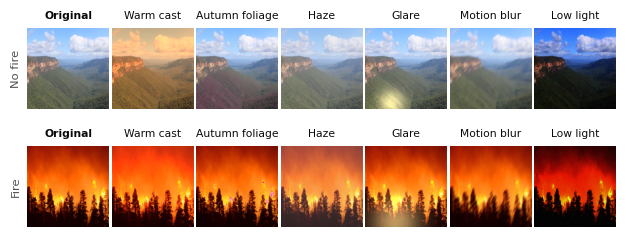

saved figures/fig2_confounder_examples.pdf and .png


In [ ]:
#@title 5 · Figure 2 — confounder-aware augmentation (re-drawn with clean spacing)
din = np.load(os.path.join(P["data"], "din_224.npz")); X_tr, y_tr = din["X_tr"], din["y_tr"]
ex = [int(np.where(y_tr == 0)[0][3]), int(np.where(y_tr == 1)[0][5])]
ops = [n for n, _ in C.CONF_OPS]
fig, ax = plt.subplots(2, len(ops) + 1, figsize=(6.9, 2.45), gridspec_kw=dict(wspace=0.04, hspace=0.32))
for r, i in enumerate(ex):
    ax[r, 0].imshow(X_tr[i])
    ax[r, 0].text(-0.08, 0.5, "No fire" if r == 0 else "Fire", transform=ax[r, 0].transAxes,
                  rotation=90, va="center", ha="right", fontsize=7.5, color=INK2)
    ax[r, 0].set_title("Original", fontsize=7, fontweight="bold", loc="center")
    for j, op in enumerate(ops):
        ax[r, j + 1].imshow(C.conf_one(X_tr[i], i, 1, force=op))
        ax[r, j + 1].set_title(op.replace("_", " ").capitalize(), fontsize=7, fontweight="normal", loc="center")
for a in ax.ravel():
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
    for sp in a.spines.values():
        sp.set_visible(False)
save(fig, "fig2_confounder_examples")

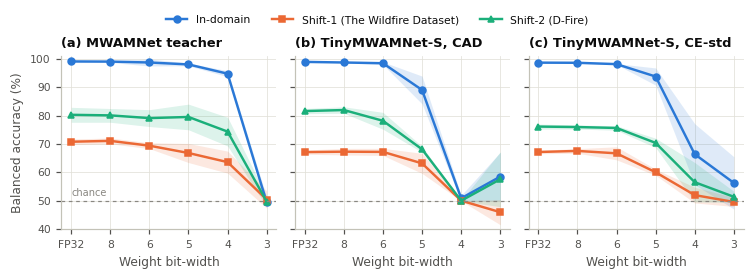

saved figures/fig3_bitwidth.pdf and .png


In [ ]:
#@title 6 · Figure 3 — weight-only bit-width sweep (teacher and TinyMWAMNet-S)
B = BW.copy(); B["key"] = np.where(B.family == "teacher", "teacher", B.arch.astype(str) + "|" + B.regime.astype(str))
order, xl = ["fp32", "w8", "w6", "w5", "w4", "w3"], ["FP32", "8", "6", "5", "4", "3"]
panels = [("teacher", "(a) MWAMNet teacher"), (f"{MAIN}|CAD", "(b) TinyMWAMNet-S, CAD"),
          (f"{MAIN}|CE-std", "(c) TinyMWAMNet-S, CE-std")]
fig, axs = plt.subplots(1, 3, figsize=(6.9, 2.35), sharey=True)
for ax, (key, title) in zip(axs, panels):
    sub = B[B.key == key]
    for d in DS:
        g = sub[sub.dataset == d].groupby("quant").bacc
        mu = np.array([g.mean().get(q, np.nan) for q in order]) * 100
        sd = np.array([g.std(ddof=1).get(q, np.nan) for q in order]) * 100
        x = np.arange(len(order))
        ax.fill_between(x, mu - sd, mu + sd, color=DS_COLOR[d], alpha=0.15, lw=0)
        ax.plot(x, mu, color=DS_COLOR[d], marker=DS_MARK[d], label=DS_LABEL[d])
    ax.axhline(50, color=MUTED, lw=0.8, ls=(0, (3, 3)))
    ax.set_xticks(range(len(order))); ax.set_xticklabels(xl); ax.set_title(title); ax.set_xlabel("Weight bit-width")
axs[0].set_ylabel("Balanced accuracy (%)"); axs[0].set_ylim(40, 101)
axs[0].text(0, 51, "chance", color=MUTED, fontsize=6.5, ha="left", va="bottom")
h, l = axs[0].get_legend_handles_labels()
fig.legend(h, l, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.07)); fig.tight_layout()
save(fig, "fig3_bitwidth")

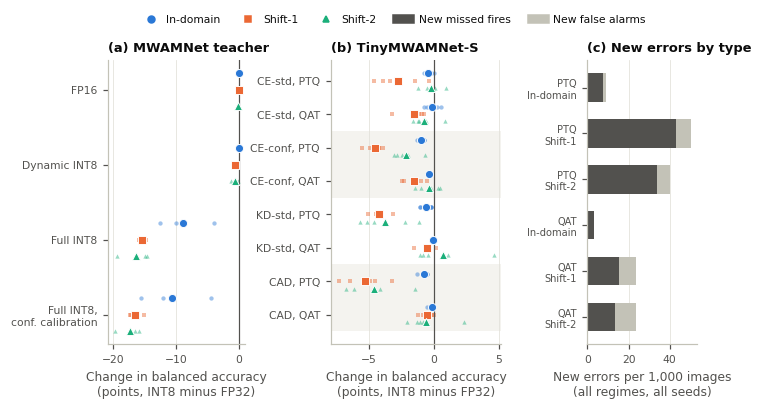

saved figures/fig4_int8_cost.pdf and .png


In [ ]:
#@title 7 · Figure 4 — what INT8 costs: in-domain versus under shift
LAD = {"fp16": "FP16", "dyn": "Dynamic INT8", "int8": "Full INT8", "int8c": "Full INT8,\nconf. calibration"}
base = TL[TL.quant == "fp32"].set_index(["seed", "dataset"]).bacc
T2 = TL[TL.quant.isin(LAD)].copy()
T2["d"] = (T2.set_index(["seed", "dataset"]).bacc.values - base.reindex(T2.set_index(["seed", "dataset"]).index).values) * 100
fig = plt.figure(figsize=(6.9, 3.35))
gs = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.25, 0.8], wspace=0.62)
ax1, ax2, ax3 = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
off = {"din": -0.22, "wild": 0.0, "dfire": 0.22}
def dots(ax, vals, y, d):
    vals = np.asarray(vals, float); vals = vals[~np.isnan(vals)]
    if not len(vals):
        return
    ax.scatter(vals, np.full(len(vals), y), s=8, color=DS_COLOR[d], alpha=0.45, lw=0, marker=DS_MARK[d])
    ax.scatter([vals.mean()], [y], s=28, color=DS_COLOR[d], marker=DS_MARK[d], edgecolor="white", lw=0.6, zorder=3)
for i, (q, lab) in enumerate(LAD.items()):
    for d in DS:
        dots(ax1, T2[(T2.quant == q) & (T2.dataset == d)].d, i + off[d], d)
ax1.set_yticks(range(len(LAD))); ax1.set_yticklabels(list(LAD.values())); ax1.invert_yaxis()
ax1.set_title("(a) MWAMNet teacher")
rows = [(r, k) for r in C.REGIMES for k in ("PTQ", "QAT")]
Dm = D[D.arch == MAIN]
for i, (r, k) in enumerate(rows):
    if i % 4 >= 2:
        ax2.axhspan(i - 0.5, i + 0.5, color=BAND, zorder=0, lw=0)
    for d in DS:
        dots(ax2, Dm[(Dm.regime == r) & (Dm.kind == k) & (Dm.dataset == d)].d_bacc * 100, i + off[d], d)
ax2.set_yticks(range(len(rows))); ax2.set_yticklabels([f"{r}, {k}" for r, k in rows]); ax2.invert_yaxis()
ax2.set_title("(b) TinyMWAMNet-S")
for ax in (ax1, ax2):
    ax.axvline(0, color=INK2, lw=0.8); ax.grid(axis="y", visible=False)
    ax.set_xlabel("Change in balanced accuracy\n(points, INT8 minus FP32)")
# (c) direction of the flips: share of compression-induced flips that are missed fires
F2 = FL[FL.arch == MAIN].groupby(["kind", "dataset"])[["n_flip", "new_missed_fires", "new_false_alarms", "n"]].sum()
labels, mf, fa = [], [], []
for k in ("PTQ", "QAT"):
    for d in DS:
        if (k, d) in F2.index:
            r_ = F2.loc[(k, d)]; labels.append(f"{k}\n{DS_SHORT[d]}")
            mf.append(1000 * r_.new_missed_fires / r_.n); fa.append(1000 * r_.new_false_alarms / r_.n)
y = np.arange(len(labels))
ax3.barh(y, mf, color=INK2, height=0.62, label="New missed fires")
ax3.barh(y, fa, left=mf, color=AXIS, height=0.62, label="New false alarms")
ax3.set_yticks(y); ax3.set_yticklabels(labels, fontsize=6.5); ax3.invert_yaxis(); ax3.grid(axis="y", visible=False)
ax3.set_xlabel("New errors per 1,000 images\n(all regimes, all seeds)"); ax3.set_title("(c) New errors by type")
h = [plt.Line2D([], [], color=DS_COLOR[d], marker=DS_MARK[d], ls="", label=DS_SHORT[d]) for d in DS]
h += [mpl.patches.Patch(color=INK2, label="New missed fires"), mpl.patches.Patch(color=AXIS, label="New false alarms")]
fig.legend(handles=h, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.03), columnspacing=1.6, handletextpad=0.4)
save(fig, "fig4_int8_cost")

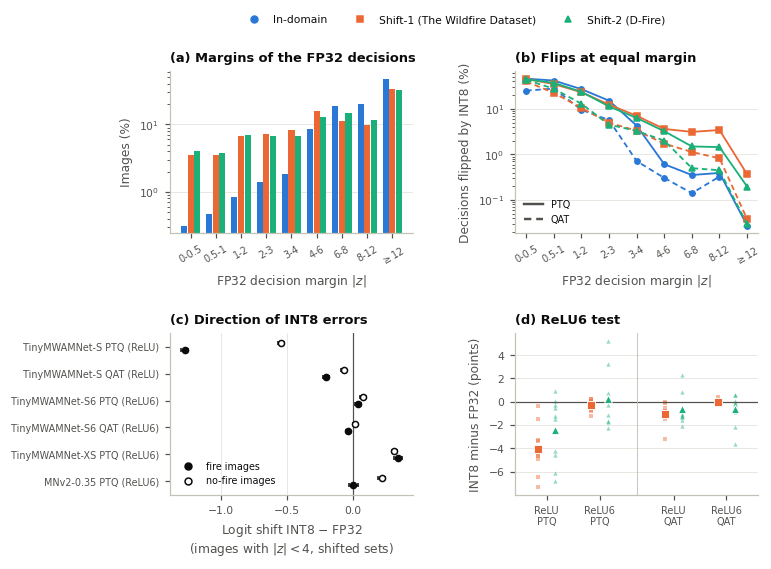

saved figures/fig5_mechanism.pdf and .png


In [ ]:
#@title 8 · Figure 5 — why in-domain tests hide the cost: decision margins and the direction of INT8 errors
NICE = {MAIN: "TinyMWAMNet-S", R6N: "TinyMWAMNet-S6", "MNv1-0.25-96": "TinyMWAMNet-XS", "MNv2-0.35-128": "MNv2-0.35"}
ACT = {MAIN: "ReLU", R6N: "ReLU6", "MNv1-0.25-96": "ReLU6", "MNv2-0.35-128": "ReLU6"}
if len(MF):                                       # fine bins (Notebook 07)
    G = MF[(MF.arch == MAIN)].groupby(["kind", "dataset", "bin_lo"]).agg(n=("n", "sum"), f=("flips", "sum")).reset_index()
    edges = sorted(G.bin_lo.unique()); hi = {e: (edges[i + 1] if i + 1 < len(edges) else np.inf) for i, e in enumerate(edges)}
    G["lab"] = [("%g-%g" % (e, hi[e])) if np.isfinite(hi[e]) else ("$\\geq$%g" % e) for e in G.bin_lo]
else:                                             # five bins (Notebook 05)
    G = MG[MG.arch == MAIN].assign(f=lambda t: t.n * t.flip_rate.fillna(0)).groupby(["kind", "dataset", "margin_bin"]).agg(
        n=("n", "sum"), f=("f", "sum")).reset_index()
    G["bin_lo"] = G.margin_bin.str.extract(r"\[([0-9.]+)").astype(float)[0]
    G["lab"] = G.margin_bin.str.replace("inf", "$\\infty$", regex=False)
G = G.sort_values("bin_lo"); bins = list(dict.fromkeys(G.bin_lo)); labs = dict(zip(G.bin_lo, G.lab))
fig, axs = plt.subplots(2, 2, figsize=(6.9, 5.0), gridspec_kw=dict(hspace=0.62, wspace=0.42))
(ax1, ax2), (ax3, ax4) = axs
# (a) how many decisions are close to the threshold
w = 0.26; x = np.arange(len(bins))
for j, d in enumerate(DS):
    g = G[(G.kind == "PTQ") & (G.dataset == d)].set_index("bin_lo").reindex(bins)
    ax1.bar(x + (j - 1) * w, 100 * g.n / g.n.sum(), width=w - 0.02, color=DS_COLOR[d], label=DS_LABEL[d])
ax1.set_xticks(x); ax1.set_xticklabels([labs[b] for b in bins], fontsize=6.3, rotation=30)
ax1.set_xlabel("FP32 decision margin $|z|$"); ax1.set_ylabel("Images (%)"); ax1.set_yscale("log")
ax1.set_title("(a) Margins of the FP32 decisions"); ax1.grid(axis="x", visible=False)
# (b) at equal margin, INT8 flips decisions equally often in-domain and under shift
for d in DS:
    for k, ls_ in (("PTQ", "-"), ("QAT", (0, (3, 2)))):
        g = G[(G.kind == k) & (G.dataset == d)].set_index("bin_lo").reindex(bins)
        r = 100 * g.f / g.n.replace(0, np.nan)
        r = r.where(r > 0)                      # a bin without flips cannot be drawn on a log axis
        ax2.plot(x, r, color=DS_COLOR[d], ls=ls_, marker=DS_MARK[d], ms=3.5, lw=1.2)
ax2.set_yscale("log"); ax2.set_xticks(x); ax2.set_xticklabels([labs[b] for b in bins], fontsize=6.3, rotation=30)
ax2.set_xlabel("FP32 decision margin $|z|$"); ax2.set_ylabel("Decisions flipped by INT8 (%)")
ax2.set_title("(b) Flips at equal margin"); ax2.grid(axis="x", visible=False)
ax2.legend(handles=[plt.Line2D([], [], color=INK2, ls="-", label="PTQ"), plt.Line2D([], [], color=INK2, ls=(0, (3, 2)), label="QAT")],
           loc="lower left", fontsize=6.3)
# (c) direction: logit shift of fragile images (Notebook 07), or the share of new errors that are missed fires
rows = [(MAIN, "PTQ"), (MAIN, "QAT"), (R6N, "PTQ"), (R6N, "QAT"), ("MNv1-0.25-96", "PTQ"), ("MNv2-0.35-128", "PTQ")]
ylab = ["%s %s (%s)" % (NICE[a], k, ACT[a]) for a, k in rows]
if len(LS):
    L = LS[LS.dataset.isin(["wild", "dfire"])].assign(w=lambda t: t.n_fragile * t.mean_dz, v=lambda t: t.n_fragile * t.se_dz ** 2 * t.n_fragile)
    for i, (a, k) in enumerate(rows):
        for c, mk, fc in ((1, "o", INK), (0, "o", "white")):
            g = L[(L.arch == a) & (L.kind == k) & (L.label == c)]
            n = g.n_fragile.sum()
            if n == 0:
                continue
            m = g.w.sum() / n; se = np.sqrt((g.n_fragile ** 2 * g.se_dz.fillna(0) ** 2).sum()) / n
            ax3.errorbar([m], [i + (0.13 if c else -0.13)], xerr=[1.96 * se], fmt=mk, mfc=fc, mec=INK, color=INK, ms=4, capsize=1.5, lw=0.8)
    ax3.axvline(0, color=INK2, lw=0.8); ax3.set_xlabel("Logit shift INT8 $-$ FP32\n(images with $|z|<4$, shifted sets)")
    ax3.legend(handles=[plt.Line2D([], [], marker="o", color=INK, ls="", label="fire images"),
                        plt.Line2D([], [], marker="o", mfc="white", mec=INK, ls="", label="no-fire images")], fontsize=6.3, loc="lower left")
    ax3.set_title("(c) Direction of INT8 errors")
else:
    F2 = FL[FL.dataset.isin(["wild", "dfire"])].groupby(["arch", "kind"])[["new_missed_fires", "broken"]].sum()
    for i, (a, k) in enumerate(rows):
        if (a, k) in F2.index:
            r_ = F2.loc[(a, k)]; ax3.barh(i, 100 * r_.new_missed_fires / max(r_.broken, 1), color=INK2 if ACT[a] == "ReLU" else AXIS, height=0.6)
    ax3.axvline(50, color=INK2, lw=0.8, ls=(0, (2, 2))); ax3.set_xlim(0, 100)
    ax3.set_xlabel("Missed fires among new INT8 errors (%)\n(shifted sets)"); ax3.set_title("(c) Direction of INT8 errors")
ax3.set_yticks(range(len(rows))); ax3.set_yticklabels(ylab, fontsize=6.3); ax3.set_ylim(len(rows) - 0.5, -0.5); ax3.grid(axis="y", visible=False)
# (d) the ReLU6 intervention: INT8 cost per seed on the shifted sets (CE-std and CAD)
grp = [(MAIN, "PTQ", 0.0), (R6N, "PTQ", 1.0), (MAIN, "QAT", 2.4), (R6N, "QAT", 3.4)]
for a, k, x0 in grp:
    for d, o in (("wild", -0.16), ("dfire", 0.16)):
        v = D[(D.arch == a) & (D.kind == k) & (D.dataset == d) & D.regime.isin(["CE-std", "CAD"])].d_bacc * 100
        ax4.scatter(np.full(len(v), x0 + o), v, s=8, color=DS_COLOR[d], alpha=0.45, lw=0, marker=DS_MARK[d])
        if len(v):
            ax4.scatter([x0 + o], [v.mean()], s=28, color=DS_COLOR[d], marker=DS_MARK[d], edgecolor="white", lw=0.6, zorder=3)
ax4.axhline(0, color=INK2, lw=0.8); ax4.axvline(1.7, color=AXIS, lw=0.6)
ax4.set_xticks([x0 for _, _, x0 in grp]); ax4.set_xticklabels(["ReLU\nPTQ", "ReLU6\nPTQ", "ReLU\nQAT", "ReLU6\nQAT"], fontsize=6.5)
ax4.set_xlim(-0.6, 4.0); ax4.set_ylabel("INT8 minus FP32 (points)"); ax4.set_title("(d) ReLU6 test"); ax4.grid(axis="x", visible=False)
h = [plt.Line2D([], [], color=DS_COLOR[d], marker=DS_MARK[d], ls="", label=DS_LABEL[d]) for d in DS]
fig.legend(handles=h, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.0))
save(fig, "fig5_mechanism")

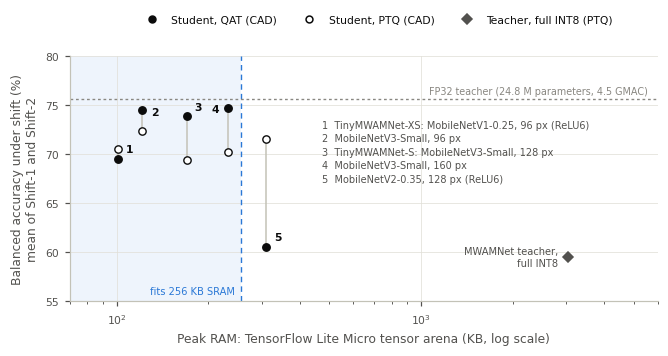

saved figures/fig6_pareto.pdf and .png


In [ ]:
#@title 9 · Figure 6 — accuracy under shift against microcontroller memory
dep = pd.read_csv(os.path.join(P["results"], "deploy_students.csv"))
T = C.load_json(os.path.join(P["results"], "deploy_teacher.json"))
KEY = {"MNv1-0.25-96": "TinyMWAMNet-XS: MobileNetV1-0.25, 96 px (ReLU6)", "MNv3S-1-96": "MobileNetV3-Small, 96 px",
       MAIN: "TinyMWAMNet-S: MobileNetV3-Small, 128 px", "MNv3S-1-160": "MobileNetV3-Small, 160 px",
       "MNv2-0.35-128": "MobileNetV2-0.35, 128 px (ReLU6)"}
def shifted(arch, kind, regime="CAD"):
    g = S[(S.arch == arch) & (S.regime == regime) & (S.kind == kind) & S.dataset.isin(["wild", "dfire"])]
    ps = g.groupby("seed").bacc.mean() * 100
    return float(ps.mean()) if len(ps) else np.nan
fig, ax = plt.subplots(figsize=(6.9, 2.9))
X0, X1 = 70, 6000
tf = TF[TF.dataset.isin(["wild", "dfire"])].groupby("seed").bacc.mean() * 100; TFM = float(tf.mean())
dep = dep[dep.model.isin(KEY)].sort_values("tflm_arena_bytes").reset_index(drop=True)
pts, labs, key = [], [], []
for i, r in dep.iterrows():
    x = r.tflm_arena_bytes / 1024; mp, mq = shifted(r.model, "PTQ"), shifted(r.model, "QAT")
    if not (np.isfinite(mp) or np.isfinite(mq)):
        continue
    if np.isfinite(mp) and np.isfinite(mq):
        ax.plot([x, x], [mp, mq], color=AXIS, lw=1.0, zorder=2)
    if np.isfinite(mp):
        ax.plot([x], [mp], "o", mfc="white", mec=INK, mew=0.9, ms=4.8, zorder=3); pts.append((x, mp))
    if np.isfinite(mq):
        ax.plot([x], [mq], "o", color=INK, ms=4.8, zorder=3); pts.append((x, mq))
    n = str(len(key) + 1); key.append(n + "  " + KEY[r.model])
    labs.append((n, x, mq if np.isfinite(mq) else mp))
tx = T["tflm_arena_bytes"] / 1024
ti = TL[(TL.quant == "int8") & TL.dataset.isin(["wild", "dfire"])].groupby("seed").bacc.mean() * 100
TIM = float(ti.mean()) if len(ti) else np.nan
if np.isfinite(TIM):
    ax.plot([tx], [TIM], "D", color=INK2, ms=4.8, zorder=3); pts.append((tx, TIM))
    ax.annotate("MWAMNet teacher,\nfull INT8", (tx, TIM), xytext=(-7, 0), textcoords="offset points", ha="right",
                va="center", fontsize=6.5, color=INK2)
ys = [p[1] for p in pts] + [TFM]
y0, y1 = 5 * np.floor((min(ys) - 3) / 5), 5 * np.ceil((max(ys) + 3) / 5)
ax.set_xscale("log"); ax.set_xlim(X0, X1); ax.set_ylim(y0, y1)
ax.axvspan(X0, 256, color="#eef4fc", lw=0, zorder=0)
ax.axvline(256, color=DS_COLOR["din"], lw=0.9, ls=(0, (4, 3)), zorder=1)
ax.text(245, y0 + 0.5, "fits 256 KB SRAM", color=DS_COLOR["din"], fontsize=6.5, ha="right", va="bottom")
ax.axhline(TFM, color=MUTED, lw=0.9, ls=(0, (2, 2)), zorder=1)
ax.text(X1 * 0.93, TFM + 0.3, "FP32 teacher (24.8 M parameters, 4.5 GMAC)", color=MUTED, fontsize=6.3, ha="right", va="bottom")
# key to the numbered students, in the empty right half (above or below the INT8 teacher)
ky = 0.74 if not np.isfinite(TIM) or (TIM - y0) / (y1 - y0) < 0.45 else 0.40
ax.text(0.43, ky, "\n".join(key), transform=ax.transAxes, fontsize=6.4, color=INK2, va="top", ha="left", linespacing=1.45)
ax.set_xlabel("Peak RAM: TensorFlow Lite Micro tensor arena (KB, log scale)")
ax.set_ylabel("Balanced accuracy under shift (%)\nmean of Shift-1 and Shift-2")
fig.legend(handles=[plt.Line2D([], [], marker="o", color=INK, ls="", label="Student, QAT (CAD)"),
                    plt.Line2D([], [], marker="o", mfc="white", mec=INK, ls="", label="Student, PTQ (CAD)"),
                    plt.Line2D([], [], marker="D", color=INK2, ls="", label="Teacher, full INT8 (PTQ)")],
           loc="upper center", ncol=3, bbox_to_anchor=(0.53, 1.04))
# number labels: the candidate position that touches no marker, line or other number
fig.canvas.draw(); rr = fig.canvas.get_renderer(); pix = [ax.transData.transform(p) for p in pts]
xv, yh = ax.transData.transform((256, y0))[0], ax.transData.transform((X0, TFM))[1]
CAND = [((5, 3), "left", "bottom"), ((-5, 3), "right", "bottom"), ((6, -1), "left", "center"), ((-6, -1), "right", "center"),
        ((0, 5), "center", "bottom"), ((5, -4), "left", "top"), ((-5, -4), "right", "top")]
done = []
for n, x, y in labs:
    best = None
    for ci, (off, ha, va) in enumerate(CAND):
        t = ax.annotate(n, (x, y), xytext=off, textcoords="offset points", ha=ha, va=va, fontsize=7, color=INK,
                        fontweight="bold")
        bb = t.get_window_extent(rr)
        sc = sum(bb.x0 - 2 < px < bb.x1 + 2 and bb.y0 - 2 < py < bb.y1 + 2 for px, py in pix) + sum(bb.overlaps(o) for o in done)
        sc += 0.5 * ((bb.x0 - 1 < xv < bb.x1 + 1) + (bb.y0 - 1 < yh < bb.y1 + 1))
        if best is None or sc < best[0]:
            if best is not None:
                best[1].remove()
            best = (sc, t, bb)
        else:
            t.remove()
        if sc == 0:
            break
    done.append(best[2])
save(fig, "fig6_pareto")

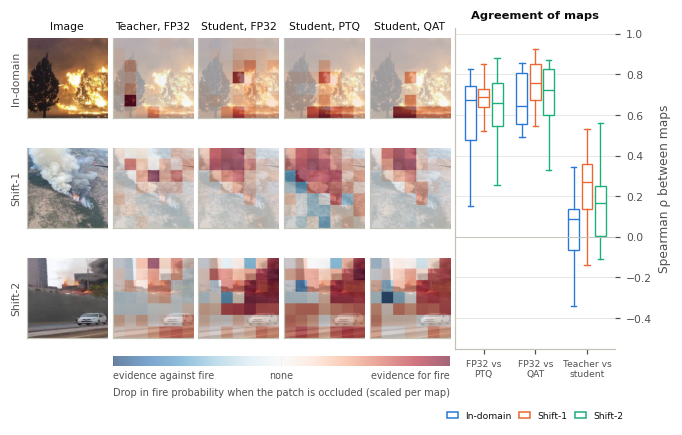

saved figures/fig7_xai.pdf and .png


In [ ]:
#@title 10 · Figure 7 — explanation stability (occlusion maps)
mp = np.load(os.path.join(A, "xai_maps.npz"), allow_pickle=True)
pick_d, pick_i = mp["pick_dataset"], mp["pick_index"]
X224 = C.load_eval_arrays(P); lab = C.labels(P)
cols = [("teacher_fp32", "Teacher, FP32"), (f"{MAIN}_fp32", "Student, FP32"), (f"{MAIN}_ptq", "Student, PTQ"),
        (f"{MAIN}_qat", "Student, QAT")]
cols = [c for c in cols if c[0] in mp.files]
show = []
for d in DS:                                        # one fire image per dataset (first in the sample)
    idx = [k for k in range(len(pick_d)) if pick_d[k] == d and lab["y_" + d][pick_i[k]] == 1]
    if idx:
        show.append(idx[0])
fig = plt.figure(figsize=(6.9, 1.08 * len(show) + 0.75))
gs = fig.add_gridspec(len(show) + 1, len(cols) + 2, width_ratios=[1] * (len(cols) + 1) + [2.0],
                      height_ratios=[1] * len(show) + [0.09], wspace=0.06, hspace=0.1)
for r, k in enumerate(show):
    img = X224[pick_d[k]][pick_i[k]]
    a = fig.add_subplot(gs[r, 0]); a.imshow(img); a.set_xticks([]); a.set_yticks([]); a.grid(False)
    a.set_ylabel(DS_SHORT[pick_d[k]], fontsize=7, color=INK2)
    if r == 0:
        a.set_title("Image", fontsize=7, fontweight="normal", loc="center")
    for c, (key, title) in enumerate(cols):
        m = mp[key][k]; v = np.abs(m).max() or 1
        a = fig.add_subplot(gs[r, c + 1]); a.imshow(img); a.grid(False)
        im = a.imshow(np.kron(m / v, np.ones((32, 32))), cmap="RdBu_r", vmin=-1, vmax=1, alpha=0.6)
        a.set_xticks([]); a.set_yticks([])
        if r == 0:
            a.set_title(title, fontsize=7, fontweight="normal", loc="center")
cax = fig.add_subplot(gs[len(show), 1:len(cols) + 1])
cb = fig.colorbar(im, cax=cax, orientation="horizontal"); cb.outline.set_visible(False)
cb.set_ticks([-1, 0, 1]); cb.set_ticklabels(["evidence against fire", "none", "evidence for fire"])
cb.ax.tick_params(labelsize=6.3, length=0); tl = cb.ax.get_xticklabels(); tl[0].set_ha("left"); tl[-1].set_ha("right")
cb.set_label("Drop in fire probability when the patch is occluded (scaled per map)", fontsize=6.5, color=INK2)
axb = fig.add_subplot(gs[:len(show), -1])
pairs = [(f"{MAIN}_fp32 vs {MAIN}_ptq", "FP32 vs\nPTQ"), (f"{MAIN}_fp32 vs {MAIN}_qat", "FP32 vs\nQAT"),
         (f"teacher_fp32 vs {MAIN}_fp32", "Teacher vs\nstudent")]
pairs = [p for p in pairs if p[0] in set(XR.pair)]
lo = 0.0
for j, (pk, plab) in enumerate(pairs):
    for o, d in zip((-0.26, 0, 0.26), DS):
        v = XR[(XR.pair == pk) & (XR.dataset == d)].spearman.dropna()
        if len(v):
            lo = min(lo, float(v.quantile(0.05)))
            bp = axb.boxplot([v], positions=[j + o], widths=0.21, patch_artist=True, showfliers=False)
            for part in ("boxes", "medians", "whiskers", "caps"):
                for el in bp[part]:
                    el.set_color(DS_COLOR[d]); el.set_linewidth(0.9)
            for el in bp["boxes"]:
                el.set_facecolor("white")
axb.set_xticks(range(len(pairs))); axb.set_xticklabels([p[1] for p in pairs], fontsize=6.0)
axb.set_xlim(-0.55, len(pairs) - 0.45); axb.set_ylim(max(-1, np.floor(lo * 4) / 4 - 0.05), 1.03)
axb.set_ylabel("Spearman ρ between maps"); axb.axhline(0, color=AXIS, lw=0.6)
axb.yaxis.set_label_position("right"); axb.yaxis.tick_right(); axb.grid(axis="x", visible=False)
axb.set_title("Agreement of maps", fontsize=7.5, loc="center")
h = [mpl.patches.Patch(facecolor="white", edgecolor=DS_COLOR[d], label=DS_SHORT[d]) for d in DS]
axb.legend(handles=h, fontsize=6, loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=3, handlelength=1.2, columnspacing=0.8)
save(fig, "fig7_xai")

In [ ]:
#@title 11 · LaTeX tables for the manuscript (tables/*.tex)
# Table 2 — teacher ladder on the common image subsets
size_mb = {}
for f in os.listdir(P["tflite"]):
    if f.startswith("T_") and f.endswith(".tflite"):
        size_mb.setdefault(f.split("_")[1], os.path.getsize(os.path.join(P["tflite"], f)) / 2**20)
lt = os.path.join(P["results"], "latency_teacher.csv")
if os.path.exists(lt):
    size_mb["fp32"] = float(pd.read_csv(lt).query("quant == 'fp32'").size_MiB.iloc[0])
names = {"fp32": "FP32", "fp16": "FP16", "dyn": "INT8 dynamic", "int8": "INT8 full (PTQ)", "int8c": "INT8 full, conf.\\ calib."}
base = TL[TL.quant == "fp32"].set_index(["seed", "dataset"]).bacc
lines = []
for q, nm in names.items():
    g = TL[TL.quant == q]
    if g.empty:
        continue
    cells = [nm, "%.1f" % size_mb.get(q, np.nan)]
    for d in DS:
        gd = g[g.dataset == d]
        cells.append(pm(gd.bacc))
        if q == "fp32":
            cells.append("---")
        else:
            dd = (gd.set_index("seed").bacc - base.xs(d, level="dataset").reindex(gd.seed).values) * 100
            fr = gd["flip_flip_rate"] * 100 if "flip_flip_rate" in gd else pd.Series(dtype=float)
            cells.append(fmt(dd.mean(), 1, plus=True) + " / " + fmt(fr.mean()))
    lines.append(" & ".join(cells) + r" \\")
write_tex("tab2_teacher_ladder.tex", "\n".join(lines) + "\n")

# Table 3 — TinyMWAMNet-S: FP32, PTQ and QAT per regime (BAcc and fire recall); teacher for reference
lines = []
tfp = TF.copy()
cells = ["Teacher (FP32, 5 seeds)", ""]
for d in DS:
    cells += [pm(tfp[tfp.dataset == d].bacc), pm(tfp[tfp.dataset == d].recall)]
lines.append(" & ".join(cells) + r" \\ \midrule")
sig = {}
for _, r in MC.iterrows():
    sig[(r.arch, r.regime, r.kind, r.dataset)] = r.p_holm < 0.05
for reg in C.REGIMES:
    for kind in ("FP32", "PTQ", "QAT"):
        g = S[(S.arch == MAIN) & (S.regime == reg) & (S.kind == kind)]
        if g.empty:
            continue
        cells = [reg if kind == "FP32" else "", kind]
        for d in DS:
            star = r"$^{*}$" if sig.get((MAIN, reg, kind, d)) else ""
            cells += [pm(g[g.dataset == d].bacc) + star, pm(g[g.dataset == d].recall)]
        lines.append(" & ".join(cells) + (r" \\ \midrule" if kind == "QAT" and reg != list(C.REGIMES)[-1] else r" \\"))
write_tex("tab3_students.tex", "\n".join(lines) + "\n")

# Table 4 — deployment
dep = pd.read_csv(os.path.join(P["results"], "deploy_students.csv"))
f6 = os.path.join(P["results"], "deploy_relu6.csv")
if os.path.exists(f6):
    dep = pd.concat([dep, pd.read_csv(f6)], ignore_index=True)
T = C.load_json(os.path.join(P["results"], "deploy_teacher.json"))
row = lambda nm, p, fl, ram, mac, u55: f"{nm} & {p} & {fl:,.1f} & {ram:,.1f} & {mac} & {u55:.2f}" + r" \\"
lines = [row("MWAMNet teacher (full INT8)", "%.2f\\,M" % (T["params"] / 1e6), T["flash_bytes"] / 1024,
             T["tflm_arena_bytes"] / 1024, "%.2f\\,G" % (T["macs"] / 1e9), T.get("vela_ms", np.nan))]
LBL = {MAIN: r"\tinyname{}-S (MNv3-S, 128)", R6N: r"\tinyname{}-S6 (ReLU6)", "MNv1-0.25-96": r"\tinyname{}-XS (MNv1-0.25, 96)",
       "MNv3S-1-96": "MNv3-S, 96", "MNv3S-1-160": "MNv3-S, 160", "MNv2-0.35-128": "MNv2-0.35, 128"}
for a in [MAIN, R6N, "MNv1-0.25-96", "MNv3S-1-96", "MNv3S-1-160", "MNv2-0.35-128"]:
    r = dep[dep.model == a]
    if r.empty:
        continue
    r = r.iloc[0]
    lines.append(row(LBL[a], "%.2f\\,M" % (r.params / 1e6), r.flash_bytes / 1024, r.tflm_arena_bytes / 1024,
                     "%.1f\\,M" % (r.macs / 1e6), r["vela_ms_ethos-u55-128"]))
write_tex("tab4_deployment.tex", "\n".join(lines) + "\n")

# Table 5 — ReLU versus ReLU6 (same seeds and data)
lines = []
for reg in ("CE-std", "CAD"):
    for a, nm in ((MAIN, "ReLU"), (R6N, "ReLU6")):
        cells = [reg if nm == "ReLU" else "", nm]
        for d in ("din", "wild", "dfire"):
            cells.append(pm(S[(S.arch == a) & (S.regime == reg) & (S.kind == "FP32") & (S.dataset == d)].bacc))
        for k in ("PTQ", "QAT"):
            for d in ("wild", "dfire"):
                cells.append(pm(D[(D.arch == a) & (D.regime == reg) & (D.kind == k) & (D.dataset == d)].d_bacc))
        f_ = FL[(FL.arch == a) & (FL.regime == reg) & (FL.kind == "PTQ") & FL.dataset.isin(["wild", "dfire"])]
        cells.append("%.0f" % (100 * f_.new_missed_fires.sum() / max(f_.broken.sum(), 1)) if len(f_) else "--")
        lines.append(" & ".join(cells) + r" \\")
write_tex("tab5_relu6.tex", "\n".join(lines) + "\n")
if len(R6):                                          # paired t-tests ReLU vs ReLU6, Holm over all comparisons
    R6["p_holm"] = C.holm(R6.p_paired_t.fillna(1).values)
    R6.to_csv(os.path.join(TAB, "relu6_tests_holm.csv"), index=False)
    print((R6.assign(cost_relu=100 * R6.cost_relu, cost_relu6=100 * R6.cost_relu6)
           [["regime", "kind", "dataset", "cost_relu", "cost_relu6", "p_paired_t", "p_holm"]]).round(3).to_string(index=False))

# Supplementary: uncorrected (Notebook 03) versus corrected QAT, XNNPACK scores for reference
old = M[(M.family == "student") & (M.quant == "qat") & M.get("eval", pd.Series(index=M.index, dtype=object)).isna()]
NAMES = {"MNv1-0.25-96": r"\tinyname{}-XS (MNv1-0.25, 96)", "MNv3S-1-96": "MNv3-S, 96", MAIN: r"\tinyname{}-S (MNv3-S, 128)",
         "MNv3S-1-160": "MNv3-S, 160", "MNv2-0.35-128": "MNv2-0.35, 128"}
ORDER = {a: i for i, a in enumerate(NAMES)}; RORDER = {r: i for i, r in enumerate(C.REGIMES)}
lines = []
for (a, reg), g in sorted(old.groupby(["arch", "regime"]), key=lambda t: (ORDER.get(t[0][0], 9), RORDER.get(t[0][1], 9))):
    fp = S[(S.arch == a) & (S.regime == reg) & (S.kind == "FP32")].set_index(["seed", "dataset"]).bacc
    new = D[(D.arch == a) & (D.regime == reg) & (D.kind == "QAT")]
    cells = [NAMES.get(a, a), reg]
    for d in DS:
        go = g[g.dataset == d].set_index("seed").bacc
        do = (go - fp.xs(d, level="dataset").reindex(go.index)).dropna()
        cells += [pm(do), pm(new[new.dataset == d].d_bacc)]
    lines.append(" & ".join(cells) + r" \\")
write_tex("tabS1_qat_old_vs_fixed.tex", "\n".join(lines) + "\n")
# Supplementary: the size family (FP32, PTQ, QAT balanced accuracy; CE-std and CAD)
FAM = [("MNv1-0.25-96", r"\tinyname{}-XS (MNv1-0.25, 96)"), ("MNv3S-1-96", "MNv3-S, 96"), (MAIN, r"\tinyname{}-S (MNv3-S, 128)"),
       ("MNv3S-1-160", "MNv3-S, 160"), ("MNv2-0.35-128", "MNv2-0.35, 128"), (R6N, r"\tinyname{}-S6 (ReLU6)")]
lines = []
for a, nm in FAM:
    for reg in ("CE-std", "CAD"):
        g = S[(S.arch == a) & (S.regime == reg)]
        if g.empty:
            continue
        cells = [nm if reg == "CE-std" else "", reg]
        for d in DS:
            for k in ("FP32", "PTQ", "QAT"):
                cells.append(pm(g[(g.kind == k) & (g.dataset == d)].bacc))
        lines.append(" & ".join(cells) + r" \\")
write_tex("tabS3_family.tex", "\n".join(lines) + "\n")

# Supplementary: activation overflow after PTQ (share of INT8 activations at a clipping limit; Notebook 05)
ONAME = {MAIN: r"\tinyname{}-S (ReLU)", "MNv3S-1-96": "MNv3-S, 96 (ReLU)", "MNv3S-1-160": "MNv3-S, 160 (ReLU)",
         R6N: r"\tinyname{}-S6 (ReLU6)", "MNv1-0.25-96": r"\tinyname{}-XS (ReLU6)", "MNv2-0.35-128": "MNv2-0.35 (ReLU6)",
         "MWAMNet": "MWAMNet teacher, full INT8"}
lines = []
for a, nm in ONAME.items():
    o = OV[(OV.arch == a) & OV.quant.isin(["ptq", "int8"])]
    if o.empty:
        continue
    cells = [nm]
    for d in DS:
        g = o[o.dataset == d]
        cells.append("%.2f" % (1e6 * (g.overflow_mean * g.n).sum() / g.n.sum()))
    for d in DS:
        g = o[o.dataset == d]
        cells.append("%.1f" % (100 * (g.any_overflow * g.n).sum() / g.n.sum()))
    g = o[o.dataset.isin(["wild", "dfire"])].assign(wf=lambda t: t.n * t.flip_rate, wk=lambda t: t.n * (1 - t.flip_rate))
    fl = (g.overflow_flipped.fillna(0) * g.wf).sum() / max(g.wf[g.overflow_flipped.notna()].sum(), 1e-12)
    kp = (g.overflow_kept.fillna(0) * g.wk).sum() / max(g.wk[g.overflow_kept.notna()].sum(), 1e-12)
    cells += ["%.2f" % (1e6 * fl), "%.2f" % (1e6 * kp)]
    lines.append(" & ".join(cells) + r" \\")
write_tex("tabS4_overflow.tex", "\n".join(lines) + "\n")

# Supplementary: key models on the microcontroller runtime (TFLM; Notebook 07)
if len(TE):
    lines = []
    for (a, reg, sd, k), g in TE.groupby(["arch", "regime", "seed", "kind"], sort=False):
        for i, d in enumerate(DS):
            r = g[g.dataset == d]
            if r.empty:
                continue
            r = r.iloc[0]
            lab = ("%s, %s, %s (seed %d)" % ("S" if a == MAIN else "S6", reg, k, sd)) if i == 0 else ""
            lines.append(" & ".join([lab, DS_SHORT[d], fmt(100 * r.bacc_fp32), fmt(100 * r.bacc_litert), fmt(100 * r.bacc_tflm),
                                     fmt(100 * r.cost_litert, plus=True), fmt(100 * r.cost_tflm, plus=True),
                                     "%.1f" % (100 * r.decision_agreement), "%.1f" % (100 * r.exact_match)]) + r" \\")
    write_tex("tabS5_tflm.tex", "\n".join(lines) + "\n")

# Supplementary: agreement between runtimes (reference kernels = what TFLM executes on the MCU)
RT = {"ref_vs_tflm": "Reference vs TFLM (raw INT8 outputs)", "ref_vs_xnnpack": "Reference vs XNNPACK (raw INT8 outputs)",
      "xnnpack_vs_ref": "Reference vs XNNPACK (decisions, all images)"}
lines = []
for comp, g in sorted(RA.groupby("comparison"), key=lambda t: list(RT).index(t[0]) if t[0] in RT else 9) if len(RA) else []:
    n_img = int(g.n.sum())
    agree = 100 * (g.decision_agreement * g.n).sum() / max(g.n.sum(), 1)
    ex = g.exact_match.dropna(); lsb = g.max_abs_lsb.dropna()
    lines.append(" & ".join([RT.get(comp, comp.replace("_", " ")), "%d" % g.model_id.nunique(), "{:,}".format(n_img),
                             "%.2f" % agree, "%.1f" % (100 * g.decision_agreement.min()),
                             ("%.1f" % (100 * ex.mean())) if len(ex) else "--",
                             ("%d" % lsb.max()) if len(lsb) else "--"]) + r" \\")
write_tex("tabS2_runtime_agreement.tex", "\n".join(lines) + "\n")
print("done")

wrote tables/tab2_teacher_ladder.tex
wrote tables/tab3_students.tex
wrote tables/tab4_deployment.tex
wrote tables/tab5_relu6.tex
regime kind dataset  cost_relu  cost_relu6  p_paired_t  p_holm
CE-std  PTQ     din     -0.421      -0.632       0.554   1.000
CE-std  PTQ    wild     -2.748      -0.515       0.020   0.203
CE-std  PTQ   dfire     -0.199       0.799       0.508   1.000
CE-std  QAT     din     -0.158      -0.579       0.306   1.000
CE-std  QAT    wild     -1.517      -0.088       0.035   0.311
CE-std  QAT   dfire     -0.747      -0.553       0.694   1.000
   CAD  PTQ     din     -0.789      -0.421       0.108   0.756
   CAD  PTQ    wild     -5.326      -0.043       0.002   0.029
   CAD  PTQ   dfire     -4.644      -0.253       0.003   0.034
   CAD  QAT     din     -0.158      -0.105       0.621   1.000
   CAD  QAT    wild     -0.530       0.003       0.091   0.729
   CAD  QAT   dfire     -0.584      -0.779       0.874   1.000
wrote tables/tabS1_qat_old_vs_fixed.tex
wrote tables

In [ ]:
#@title 12 · Summary
for sub in (FIG, TAB):
    print(sub); [print("   ", f) for f in sorted(os.listdir(sub))]

/content/drive/MyDrive/TinyMWAMNet/figures
    fig2_confounder_examples.pdf
    fig2_confounder_examples.png
    fig3_bitwidth.pdf
    fig3_bitwidth.png
    fig4_int8_cost.pdf
    fig4_int8_cost.png
    fig5_mechanism.pdf
    fig5_mechanism.png
    fig6_pareto.pdf
    fig6_pareto.png
    fig7_xai.pdf
    fig7_xai.png
/content/drive/MyDrive/TinyMWAMNet/tables
    relu6_tests_holm.csv
    tab2_teacher_ladder.tex
    tab3_students.tex
    tab4_deployment.tex
    tab5_relu6.tex
    tabS1_qat_old_vs_fixed.tex
    tabS2_runtime_agreement.tex
    tabS3_family.tex
    tabS4_overflow.tex
    tabS5_tflm.tex
